# Прогнозирование температуры сплава

## Введение

### Описание проекта

Чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» хочет снизить потребление электроэнергии на этапе обработки стали.

Для этого необходимо контролировать температуру сплава в процессе обработки. В рамках проекта требуется построить модель машинного обучения, способную предсказывать финальную температуру сплава по данным о нагреве, продувке газом и добавлении легирующих материалов.

Полученная модель может быть использована для имитации технологического процесса и дальнейшей оптимизации энергозатрат.

### Описание технологического процесса

Сталь обрабатывают в металлическом ковше вместимостью около 100 тонн, облицованном огнеупорным кирпичом. Расплавленную сталь заливают в ковш и подогревают до нужной температуры графитовыми электродами.

Во время обработки из сплава выводится сера, корректируется химический состав, добавляются легирующие материалы, а также проводится продувка инертным газом. После каждого этапа выполняются замеры температуры и химический анализ.

Такой цикл может повторяться несколько раз, пока не будут достигнуты требуемые характеристики сплава. После этого сталь либо отправляется на доводку, либо поступает в машину непрерывной разливки.

### Цель исследования

Построить модель машинного обучения, предсказывающую финальную температуру сплава на этапе обработки стали.

Результаты модели планируется использовать для имитации технологического процесса и потенциальной оптимизации производственных расходов за счёт более эффективного управления энергопотреблением.

**Критерий качества:** MAE ≤ 6.8 °C

### Описание данных

Данные состоят из нескольких файлов, полученных из разных источников:

- `data_arc_new.csv` — данные об электродах;
- `data_bulk_new.csv` — данные о подаче сыпучих материалов (объём);
- `data_bulk_time_new.csv` — данные о подаче сыпучих материалов (время);
- `data_gas_new.csv` — данные о продувке сплава газом;
- `data_temp_new.csv` — результаты измерения температуры;
- `data_wire_new.csv` — данные о проволочных материалах (объём);
- `data_wire_time_new.csv` — данные о проволочных материалах (время).

### `data_arc_new.csv`
- `key` — номер партии;
- `Начало нагрева дугой` — время начала нагрева;
- `Конец нагрева дугой` — время окончания нагрева;
- `Активная мощность` — значение активной мощности;
- `Реактивная мощность` — значение реактивной мощности.

### `data_bulk_new.csv`
- `key` — номер партии;
- `Bulk 1` … `Bulk 15` — объём подаваемого материала.

### `data_bulk_time_new.csv`
- `key` — номер партии;
- `Bulk 1` … `Bulk 15` — время подачи материала.

### `data_gas_new.csv`
- `key` — номер партии;
- `Газ 1` — объём подаваемого газа.

### `data_temp_new.csv`
- `key` — номер партии;
- `Время замера` — время замера;
- `Температура` — значение температуры.

### `data_wire_new.csv`
- `key` — номер партии;
- `Wire 1` … `Wire 9` — объём подаваемых проволочных материалов.

### `data_wire_time_new.csv`
- `key` — номер партии;
- `Wire 1` … `Wire 9` — время подачи проволочных материалов.

Во всех файлах столбец `key` содержит номер партии. В таблицах может быть несколько строк с одинаковым значением `key`, поскольку они соответствуют разным итерациям обработки одной и той же партии.

### План исследования

1. Загрузить данные и выполнить первичный осмотр таблиц.
2. Провести исследовательский анализ и предобработку каждого набора данных.
3. Определить, какие признаки целесообразно использовать для моделирования.
4. Агрегировать данные по номеру партии и объединить таблицы в единый датасет.
5. Сформировать целевой признак и подготовить итоговую обучающую выборку.
6. Провести исследовательский анализ объединённого датасета, изучить распределения признаков и корреляции.
7. При необходимости сгенерировать новые признаки, отражающие особенности технологического процесса.
8. Подготовить данные к обучению моделей.
9. Обучить несколько моделей машинного обучения и подобрать гиперпараметры как минимум для одной из них.
10. Выбрать лучшую модель и проверить её качество на тестовой выборке.
11. Сформулировать общий вывод и рекомендации для заказчика.

## Загрузка данных и первичный осмотр

На первом этапе загрузим все таблицы и проверим их общую структуру: размер, типы данных, наличие пропусков и дубликатов, а также корректность названий признаков.

Поскольку данные получены из разных источников и описывают разные аспекты одного технологического процесса, важно убедиться, что таблицы можно будет корректно сопоставить по номеру партии `key`.

### Импорт библиотек

Сначала импортируем библиотеки, необходимые для загрузки данных, анализа, визуализации и обучения моделей.

In [1]:
#!pip install shap --upgrade --quiet
#!pip install numba==0.57.0 --quiet
#!pip install -U scikit-learn lightgbm pandas matplotlib seaborn jinja2



In [2]:
#!pip install phik -q

In [3]:
# стандартные библиотеки
import warnings

# работа с данными
import numpy as np
import pandas as pd

# визуализация
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

# phik-корреляция
from phik import phik_matrix


# препроцессинг и моделирование
import sklearn
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

# модели
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

# распределения для RandomizedSearchCV и статистический тест
from scipy.stats import randint, uniform, wilcoxon

# shap для интерпретации моделей
import shap 

RANDOM_STATE = 310326  # дата начала проекта 

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# директория для сохранения изображений
from pathlib import Path


IMG_DIR = Path("../images")
IMG_DIR.mkdir(exist_ok=True)

def save_plot(name: str, dpi: int = 300):
    plt.tight_layout()
    plt.savefig(IMG_DIR / f"{name}.png", dpi=dpi, bbox_inches="tight")
    print(f"Saved: {IMG_DIR / f'{name}.png'}")


In [4]:
print("sklearn:", sklearn.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

sklearn: 1.6.1
numpy: 2.1.3
pandas: 2.3.1


### Загрузка данных

Загружу все исходные таблицы и сохраню их в отдельные датафреймы для дальнейшего анализа.

In [5]:
# загрузка данных
file_map = {
    'arc': 'data_arc_new.csv',
    'bulk': 'data_bulk_new.csv',
    'bulk_time': 'data_bulk_time_new.csv',
    'gas': 'data_gas_new.csv',
    'temp': 'data_temp_new.csv',
    'wire': 'data_wire_new.csv',
    'wire_time': 'data_wire_time_new.csv'
}

base_paths = ('/datasets/', '../data/')
dfs = {}
loaded_from = {}

for name, filename in file_map.items():
    for base in base_paths:
        path = f'{base}{filename}'
        try:
            dfs[name] = pd.read_csv(path)
            loaded_from[name] = path
            break
        except FileNotFoundError:
            continue
    else:
        raise FileNotFoundError(f'Файл не найден: {filename}')

print('Загруженные таблицы (rows, cols):')
for name, df in dfs.items():
    print(f'{name:10s} {df.shape} <- {loaded_from[name]}')

Загруженные таблицы (rows, cols):
arc        (14876, 5) <- ../data/data_arc_new.csv
bulk       (3129, 16) <- ../data/data_bulk_new.csv
bulk_time  (3129, 16) <- ../data/data_bulk_time_new.csv
gas        (3239, 2) <- ../data/data_gas_new.csv
temp       (18092, 3) <- ../data/data_temp_new.csv
wire       (3081, 10) <- ../data/data_wire_new.csv
wire_time  (3081, 10) <- ../data/data_wire_time_new.csv


Все исходные таблицы успешно загружены.

Данные представлены в семи отдельных файлах и описывают разные этапы обработки стали: нагрев электродами, подачу сыпучих и проволочных материалов, продувку газом и измерение температуры.

По размеру таблиц видно, что количество записей в них различается. Это ожидаемо, поскольку один и тот же номер партии может встречаться несколько раз: разные таблицы фиксируют разные события и итерации обработки.

Наиболее детализированными являются таблицы с данными об электродах и температуре:
- `arc` содержит 14 876 строк;
- `temp` содержит 18 092 строки.

Это указывает на то, что в рамках одной партии могло выполняться несколько циклов нагрева и несколько измерений температуры.
На следующем этапе необходимо проверить типы данных, наличие пропусков, дубликатов и количество уникальных партий в каждой таблице.

### Первичный осмотр данных

Проверю размер таблиц, первые строки, типы данных и наличие пропусков.

In [6]:
# Первичный осмотр данных:
# - .info(): количество строк, пропуски, типы данных
# - .head(): первые 5 строк таблицы

for name, df in dfs.items():
    if df is not None:
        print("="*60)
        print(f"\n{name.upper()} — INFO:")
        df.info()
        print(f"\n{name.upper()} — HEAD:")
        display(df.head())
        describe = df.describe()
        print(f"\n{name.upper()} — DESCRIBE:")
        display(describe)


ARC — INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   Начало нагрева дугой  14876 non-null  object 
 2   Конец нагрева дугой   14876 non-null  object 
 3   Активная мощность     14876 non-null  float64
 4   Реактивная мощность   14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB

ARC — HEAD:


,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691



ARC — DESCRIBE:


,key,Активная мощность,Реактивная мощность
count,14876.000000,14876.000000,14876.000000
mean,1615.220422,0.662752,0.438986
std,934.571502,0.258885,5.873485
min,1.000000,0.223120,-715.479924
25%,806.000000,0.467115,0.337175
50%,1617.000000,0.599587,0.441639
75%,2429.000000,0.830070,0.608201
max,3241.000000,1.463773,1.270284



BULK — INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     float64
 6   Bulk 6   576 non-null    float64
 7   Bulk 7   25 non-null     float64
 8   Bulk 8   1 non-null      float64
 9   Bulk 9   19 non-null     float64
 10  Bulk 10  176 non-null    float64
 11  Bulk 11  177 non-null    float64
 12  Bulk 12  2450 non-null   float64
 13  Bulk 13  18 non-null     float64
 14  Bulk 14  2806 non-null   float64
 15  Bulk 15  2248 non-null   float64
dtypes: float64(15), int64(1)
memory usage: 391.3 KB

BULK — HEAD:


...

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3081.000000,3055.000000,1079.000000,63.000000,14.000000,1.000,73.000000,11.000000,19.000000,29.000000
mean,1623.426485,100.895853,50.577323,189.482681,57.442841,15.132,48.016974,10.039007,53.625193,34.155752
std,932.996726,42.012518,39.320216,99.513444,28.824667,NaN,33.919845,8.610584,16.881728,19.931616
min,1.000000,1.918800,0.030160,0.144144,24.148801,15.132,0.034320,0.234208,45.076721,4.622800
25%,823.000000,72.115684,20.193680,95.135044,40.807002,15.132,25.053600,6.762756,46.094879,22.058401
50%,1619.000000,100.158234,40.142956,235.194977,45.234282,15.132,42.076324,9.017009,46.279999,30.066399
75%,2434.000000,126.060483,70.227558,276.252014,76.124619,15.132,64.212723,11.886057,48.089603,43.862003
max,3241.000000,330.314424,282.780152,385.008668,113.231044,15.132,180.454575,32.847674,102.762401,90.053604



WIRE_TIME — INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   key     3081 non-null   int64 
 1   Wire 1  3055 non-null   object
 2   Wire 2  1079 non-null   object
 3   Wire 3  63 non-null     object
 4   Wire 4  14 non-null     object
 5   Wire 5  1 non-null      object
 6   Wire 6  73 non-null     object
 7   Wire 7  11 non-null     object
 8   Wire 8  19 non-null     object
 9   Wire 9  29 non-null     object
dtypes: int64(1), object(9)
memory usage: 240.8+ KB

WIRE_TIME — HEAD:


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2019-05-03 12:11:46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2019-05-03 12:43:22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,NaN,NaN,NaN,NaN,NaN,NaN,NaN



WIRE_TIME — DESCRIBE:


,key
count,3081.000000
mean,1623.426485
std,932.996726
min,1.000000
25%,823.000000
50%,1619.000000
75%,2434.000000
max,3241.000000


In [7]:
for name, df in dfs.items():
	if df is not None:
		print("=" * 60)
		print(f"{name.upper()} — пропуски")
		print(df.isna().sum())

		print(f"{name.upper()} — полные дубликаты")
		print(df.duplicated().sum())

		print(f"{name.upper()} — число уникальных key")
		if 'key' in df.columns:
			print(df['key'].nunique())
		else:
			print("Столбец 'key' отсутствует")

ARC — пропуски
key                     0
Начало нагрева дугой    0
Конец нагрева дугой     0
Активная мощность       0
Реактивная мощность     0
dtype: int64
ARC — полные дубликаты
0
ARC — число уникальных key
3214
BULK — пропуски
key           0
Bulk 1     2877
Bulk 2     3107
Bulk 3     1831
Bulk 4     2115
Bulk 5     3052
Bulk 6     2553
Bulk 7     3104
Bulk 8     3128
Bulk 9     3110
Bulk 10    2953
Bulk 11    2952
Bulk 12     679
Bulk 13    3111
Bulk 14     323
Bulk 15     881
dtype: int64
BULK — полные дубликаты
0
BULK — число уникальных key
3129
BULK_TIME — пропуски
key           0
Bulk 1     2877
Bulk 2     3107
Bulk 3     1831
Bulk 4     2115
Bulk 5     3052
Bulk 6     2553
Bulk 7     3104
Bulk 8     3128
Bulk 9     3110
Bulk 10    2953
Bulk 11    2952
Bulk 12     679
Bulk 13    3111
Bulk 14     323
Bulk 15     881
dtype: int64
BULK_TIME — полные дубликаты
0
BULK_TIME — число уникальных key
3129
GAS — пропуски
key      0
Газ 1    0
dtype: int64
GAS — полные дубликаты
0
GAS — ч

## Вывод по первичному осмотру

Все таблицы успешно загружены и проверены на базовом уровне. Полные дубликаты в исходных данных отсутствуют. Число уникальных партий между таблицами различается, что соответствует логике технологического процесса. Пропуски в таблицах материалов в основном связаны с отсутствием подачи конкретных добавок, тогда как пропуски в таблице температур требуют отдельного внимания, поскольку именно на её основе будет формироваться целевой признак.

После первичного осмотра можно перейти к содержательному анализу отдельных таблиц и определить, какие признаки следует использовать при построении итогового датасета.

## Исследовательский анализ и предобработка отдельных таблиц

На этапе первичного осмотра все таблицы были проверены по единой схеме. Такой подход удобен для базовой диагностики структуры данных, пропусков, дубликатов и числа уникальных партий.

Однако для дальнейшего исследовательского анализа этого недостаточно. Таблицы различаются по смыслу, структуре и роли в проекте, поэтому далее каждая из них будет рассмотрена отдельно. Такой подход позволяет не упустить важные особенности данных и корректно определить логику их последующей предобработки и объединения.

### Таблица `arc`

Таблица `arc` содержит данные о нагреве партии электродами. Для одной партии может быть зафиксировано несколько этапов нагрева, поэтому таблица представлена в событийном формате: одна строка соответствует одному интервалу работы электродов.

На основе этих данных можно сформировать признаки, связанные с интенсивностью и длительностью нагрева. Именно они, вероятно, будут оказывать заметное влияние на финальную температуру сплава.

In [8]:
# таблица arc: анализ и подготовка к агрегации
arc_df = dfs['arc'].copy()

# приведение типов
dt_cols = ['Начало нагрева дугой', 'Конец нагрева дугой']
pow_cols = ['Активная мощность', 'Реактивная мощность']

for col in dt_cols:
    arc_df[col] = pd.to_datetime(arc_df[col], errors='coerce')

for col in pow_cols:
    arc_df[col] = pd.to_numeric(arc_df[col], errors='coerce')

# генерация признаков
arc_df['heating_time_sec'] = (
    arc_df['Конец нагрева дугой'] - arc_df['Начало нагрева дугой']
).dt.total_seconds()

arc_df['full_power'] = np.sqrt(
    arc_df['Активная мощность']**2 + arc_df['Реактивная мощность']**2
)

# прокси-оценки работы нагрева
arc_df['energy_active'] = arc_df['Активная мощность'] * arc_df['heating_time_sec']
arc_df['energy_full'] = arc_df['full_power'] * arc_df['heating_time_sec']

# контроль качества
bad_dt = arc_df[dt_cols].isna().any(axis=1)
bad_time_neg = arc_df['heating_time_sec'] < 0
bad_time_zero = arc_df['heating_time_sec'] == 0
bad_active = arc_df['Активная мощность'] < 0
bad_reactive = arc_df['Реактивная мощность'] < 0
bad_any = bad_dt | bad_time_neg | bad_time_zero | bad_active | bad_reactive

quality_report = pd.Series({
    'rows_total': len(arc_df),
    'datetime_na_rows': int(bad_dt.sum()),
    'heating_time_sec < 0': int(bad_time_neg.sum()),
    'heating_time_sec == 0': int(bad_time_zero.sum()),
    'active_power < 0': int(bad_active.sum()),
    'reactive_power < 0': int(bad_reactive.sum()),
    'rows_with_any_issue': int(bad_any.sum())
}, name='value')

print('Контроль качества arc:')
display(quality_report.to_frame())

print('Описание числовых признаков:')
display(
    arc_df[
        ['Активная мощность', 'Реактивная мощность',
         'heating_time_sec', 'full_power',
         'energy_active', 'energy_full']
    ].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
)

print('Проблемные строки (до 10):')
display(arc_df.loc[bad_any].head(10))

print('Топ-10 самых длинных этапов нагрева:')
display(arc_df.sort_values('heating_time_sec', ascending=False).head(10))

print('Распределение числа этапов нагрева на партию:')
heats_per_key = arc_df.groupby('key').size()
display(heats_per_key.describe(percentiles=[0.01, 0.05, 0.95, 0.99]))

# очищенная версия для дальнейшей агрегации
arc_df_clean = arc_df.loc[
    (~bad_dt) &
    (arc_df['heating_time_sec'] > 0) &
    (arc_df['Активная мощность'] >= 0) &
    (arc_df['Реактивная мощность'] >= 0)
].copy()

print(f'После очистки осталось {arc_df_clean.shape[0]} строк из {arc_df.shape[0]}')

Контроль качества arc:


,value
rows_total,14876
datetime_na_rows,0
heating_time_sec < 0,0
heating_time_sec == 0,0
active_power < 0,0
reactive_power < 0,1
rows_with_any_issue,1


Описание числовых признаков:


,Активная мощность,Реактивная мощность,heating_time_sec,full_power,energy_active,energy_full
count,14876.000000,14876.000000,14876.000000,14876.000000,14876.000000,14876.000000
mean,0.662752,0.438986,171.670946,0.871425,114.044276,146.879972
std,0.258885,5.873485,98.186803,5.868339,83.006059,646.540055
min,0.223120,-715.479924,11.000000,0.275718,5.246505,6.409531
1%,0.270028,0.193644,32.000000,0.336563,15.699402,19.381500
5%,0.322024,0.231851,58.000000,0.399350,28.044362,35.014673
50%,0.599587,0.441639,147.000000,0.746591,92.194117,114.486341
95%,1.179585,0.875253,360.250000,1.469217,274.454217,342.025444
99%,1.335955,1.032311,508.250000,1.668563,410.330780,508.350253
max,1.463773,1.270284,907.000000,715.480272,898.200876,77987.349613


Проблемные строки (до 10):


...

Топ-10 самых длинных этапов нагрева:


,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность,heating_time_sec,full_power,energy_active,energy_full
7799,1689,2019-07-05 11:30:50,2019-07-05 11:45:57,0.966775,0.675200,907.0,1.179215,876.864925,1069.548361
12424,2701,2019-08-18 00:40:31,2019-08-18 00:54:17,1.027288,0.769083,826.0,1.283281,848.539888,1059.989839
7433,1616,2019-07-03 00:41:18,2019-07-03 00:54:18,0.471394,0.369249,780.0,0.598796,367.687320,467.061191
2939,640,2019-05-28 03:01:03,2019-05-28 03:13:29,0.278164,0.190246,746.0,0.337000,207.510344,251.401725
4654,1005,2019-06-11 05:56:02,2019-06-11 06:08:07,0.944134,0.691533,725.0,1.170302,684.497150,848.468990
2661,580,2019-05-25 10:29:58,2019-05-25 10:42:02,0.923686,0.600245,724.0,1.101585,668.748664,797.547663
9226,2001,2019-07-23 12:02:33,2019-07-23 12:14:34,0.676336,0.498140,721.0,0.839984,487.638256,605.628775
14200,3086,2019-09-01 08:46:32,2019-09-01 08:58:33,0.351570,0.264692,721.0,0.440072,253.481970,317.291875
11740,2560,2019-08-12 17:24:43,2019-08-12 17:36:44,0.396961,0.330951,721.0,0.516824,286.208881,372.629792
1439,312,2019-05-15 12:04:31,2019-05-15 12:15:56,0.857520,0.736287,685.0,1.130247,587.401200,774.219442


Распределение числа этапов нагрева на партию:


count    3214.000000
mean        4.628500
std         1.608647
min         1.000000
1%          1.000000
5%          2.000000
50%         4.000000
95%         7.000000
99%         9.000000
max        16.000000
dtype: float64

После очистки осталось 14875 строк из 14876


По таблице `arc` временные признаки были успешно переведены в формат `datetime`, после чего для каждого этапа нагрева рассчитана его длительность в секундах. Дополнительно были сформированы производные признаки: полная мощность, а также условные показатели интенсивности нагрева с учётом времени.

Проверка качества данных показала, что:
- пропуски во временных и числовых признаках отсутствуют;
- отрицательной или нулевой длительности нагрева не обнаружено;
- отрицательных значений активной мощности нет;
- обнаружена одна аномальная строка с отрицательным значением реактивной мощности.

Эта запись выглядит как явная ошибка данных, поскольку по модулю значение реактивной мощности многократно превышает типичный диапазон наблюдений и приводит к аномально завышенной полной мощности. Поэтому данную строку целесообразно исключить из дальнейшего анализа.

После очистки в таблице осталось 14 875 строк из 14 876, то есть потери данных минимальны.

Также было установлено, что на одну партию в среднем приходится около 4–5 этапов нагрева, медианное значение равно 4, а максимальное число этапов достигает 16. Это подтверждает, что таблица `arc` содержит повторяющиеся события по одной партии и требует агрегации по `key` перед объединением с другими источниками данных.

**Вывод:** таблица `arc` в целом имеет хорошее качество. После удаления одной аномальной строки её можно использовать для дальнейшей агрегации признаков, связанных с длительностью и интенсивностью нагрева партии.

In [9]:
# удаляем партии целиком: объект моделирования — ковш (key), не отдельная строка
bad_keys = arc_df.loc[bad_any, 'key'].unique()
arc_df_clean = arc_df[~arc_df['key'].isin(bad_keys)].copy()

print(f'Партий с проблемными строками: {len(bad_keys)}')
print(f'После очистки осталось {arc_df_clean.shape[0]} строк из {arc_df.shape[0]}')


Партий с проблемными строками: 1
После очистки осталось 14872 строк из 14876



Поскольку объектом моделирования является партия стали (`key`), а не отдельный этап нагрева, было принято решение исключить из дальнейшего анализа всю партию целиком, а не только проблемную строку. Такой подход позволяет избежать искажения агрегированных признаков по нагреву.

После очистки из таблицы были удалены данные по одной партии: осталось 14 872 строки из 14 876. Потери данных несущественны и не должны повлиять на итоговое качество модели.

**Вывод:** таблица `arc` в целом имеет хорошее качество. После исключения одной проблемной партии её можно использовать для дальнейшей агрегации признаков, связанных с длительностью и интенсивностью нагрева.

### Таблицы `bulk` и `bulk_time`

Таблицы `bulk` и `bulk_time` рассматриваю совместно, поскольку они описывают один и тот же этап обработки партии. Первая таблица содержит объёмы подаваемых сыпучих материалов, вторая — время их подачи. Такой совместный анализ позволяет оценить как состав добавок, так и временную структуру их внесения.

Для этих таблиц важно проверить согласованность структуры, природу пропусков и частоту использования разных типов материалов. Это позволит понять, какие признаки можно использовать напрямую, а какие лучше агрегировать.

In [10]:
# таблицы bulk и bulk_time: углублённый анализ и подготовка
bulk_df = dfs['bulk'].copy()
bulk_time_df = dfs['bulk_time'].copy()

# признаки материалов
bulk_cols = sorted([c for c in bulk_df.columns if c != 'key'])
bulk_time_cols = sorted([c for c in bulk_time_df.columns if c != 'key'])

# проверка структуры
print('Совпадают ли наборы столбцов:', set(bulk_df.columns) == set(bulk_time_df.columns))
print('Совпадают ли списки material-колонок:', bulk_cols == bulk_time_cols)
print()

# приведение типов
bulk_df[bulk_cols] = bulk_df[bulk_cols].apply(pd.to_numeric, errors='coerce')
for col in bulk_time_cols:
	bulk_time_df[col] = pd.to_datetime(bulk_time_df[col], errors='coerce')

# контроль ключей и дублей
print('Дубликаты key в bulk:', bulk_df['key'].duplicated().sum())
print('Дубликаты key в bulk_time:', bulk_time_df['key'].duplicated().sum())
print('Уникальных key в bulk:', bulk_df['key'].nunique())
print('Уникальных key в bulk_time:', bulk_time_df['key'].nunique())
print('key только в bulk:', bulk_df.loc[~bulk_df['key'].isin(bulk_time_df['key']), 'key'].nunique())
print('key только в bulk_time:', bulk_time_df.loc[~bulk_time_df['key'].isin(bulk_df['key']), 'key'].nunique())
print()

# согласованность пропусков (после выравнивания по key)
bulk_na_mask = (
	bulk_df.set_index('key')[bulk_cols]
	.sort_index()
	.isna()
	.groupby(level=0)
	.all()
)

bulk_time_na_mask = (
	bulk_time_df.set_index('key')[bulk_time_cols]
	.sort_index()
	.isna()
	.groupby(level=0)
	.all()
)

common_keys = bulk_na_mask.index.intersection(bulk_time_na_mask.index)
same_missing_mask = bulk_na_mask.loc[common_keys].equals(bulk_time_na_mask.loc[common_keys])

print('Совпадает ли структура пропусков bulk и bulk_time (по общим key):', same_missing_mask)
print()

# базовая статистика заполненности
bulk_non_null = bulk_df[bulk_cols].notna().sum().sort_values(ascending=False)
bulk_time_non_null = bulk_time_df[bulk_time_cols].notna().sum().sort_values(ascending=False)

print('Число непустых значений по bulk-признакам:')
display(bulk_non_null.to_frame(name='non_null_count'))

print('Число непустых временных значений по bulk_time-признакам:')
display(bulk_time_non_null.to_frame(name='non_null_count'))

# контроль аномалий в объемах
neg_count = int((bulk_df[bulk_cols] < 0).sum().sum())
print(f'Отрицательных значений в bulk-признаках: {neg_count}')
print()

# агрегация bulk по key (на случай повторов)
bulk_agg = (
	bulk_df.groupby('key', as_index=False)[bulk_cols]
	.sum(min_count=1)
)

bulk_agg[bulk_cols] = bulk_agg[bulk_cols].fillna(0)
bulk_agg['bulk_total'] = bulk_agg[bulk_cols].sum(axis=1)
bulk_agg['bulk_types_used'] = (bulk_agg[bulk_cols] > 0).sum(axis=1)
bulk_agg['bulk_max_single'] = bulk_agg[bulk_cols].max(axis=1)

print('Описание агрегированных признаков bulk:')
display(
	bulk_agg[['bulk_total', 'bulk_types_used', 'bulk_max_single']]
	.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
)

# агрегация временных признаков bulk_time по key
bulk_time_long = (
	bulk_time_df
	.set_index('key')[bulk_time_cols]
	.stack(dropna=True)
	.rename('event_time')
	.reset_index()
)

bulk_time_features = (
	bulk_time_long.groupby('key', as_index=False)
	.agg(
		bulk_time_first=('event_time', 'min'),
		bulk_time_last=('event_time', 'max'),
		bulk_time_count=('event_time', 'count')
	)
)

bulk_time_features['bulk_time_span_sec'] = (
	bulk_time_features['bulk_time_last'] - bulk_time_features['bulk_time_first']
).dt.total_seconds()

# key без событий в bulk_time
all_bulk_keys = pd.DataFrame({'key': bulk_df['key'].drop_duplicates().sort_values()})
bulk_time_features = all_bulk_keys.merge(bulk_time_features, on='key', how='left')
bulk_time_features['bulk_time_count'] = bulk_time_features['bulk_time_count'].fillna(0).astype(int)
bulk_time_features['bulk_time_span_sec'] = bulk_time_features['bulk_time_span_sec'].fillna(0)

print('Описание временных признаков bulk_time:')
display(
	bulk_time_features[['bulk_time_count', 'bulk_time_span_sec']]
	.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
)

print('Топ материалов по частоте использования:')
display(bulk_non_null.head(10))

print('Пример подготовленных данных bulk (агрегировано по key):')
display(bulk_agg[['key', 'bulk_total', 'bulk_types_used', 'bulk_max_single'] + bulk_cols[:5]].head())

print('Пример подготовленных данных bulk_time:')
display(bulk_time_features.head())

Совпадают ли наборы столбцов: True
Совпадают ли списки material-колонок: True

Дубликаты key в bulk: 0
Дубликаты key в bulk_time: 0
Уникальных key в bulk: 3129
Уникальных key в bulk_time: 3129
key только в bulk: 0
key только в bulk_time: 0

Совпадает ли структура пропусков bulk и bulk_time (по общим key): True

Число непустых значений по bulk-признакам:


,non_null_count
Bulk 14,2806
Bulk 12,2450
Bulk 15,2248
Bulk 3,1298
Bulk 4,1014
Bulk 6,576
Bulk 1,252
Bulk 11,177
Bulk 10,176
Bulk 5,77


Число непустых временных значений по bulk_time-признакам:


,non_null_count
Bulk 14,2806
Bulk 12,2450
Bulk 15,2248
Bulk 3,1298
Bulk 4,1014
Bulk 6,576
Bulk 1,252
Bulk 11,177
Bulk 10,176
Bulk 5,77


Отрицательных значений в bulk-признаках: 0

Описание агрегированных признаков bulk:


...

Bulk 14    2806
Bulk 12    2450
Bulk 15    2248
Bulk 3     1298
Bulk 4     1014
Bulk 6      576
Bulk 1      252
Bulk 11     177
Bulk 10     176
Bulk 5       77
dtype: int64

Пример подготовленных данных bulk (агрегировано по key):


,key,bulk_total,bulk_types_used,bulk_max_single,Bulk 1,Bulk 10,Bulk 11,Bulk 12,Bulk 13
0,1,553.0,4,206.0,0.0,0.0,0.0,206.0,0.0
1,2,582.0,4,206.0,0.0,0.0,0.0,206.0,0.0
2,3,544.0,4,205.0,0.0,0.0,0.0,205.0,0.0
3,4,595.0,4,207.0,0.0,0.0,0.0,207.0,0.0
4,5,584.0,4,203.0,0.0,0.0,0.0,203.0,0.0


Пример подготовленных данных bulk_time:


,key,bulk_time_first,bulk_time_last,bulk_time_count,bulk_time_span_sec
0,1,2019-05-03 11:10:43,2019-05-03 11:28:48,4,1085.0
1,2,2019-05-03 11:36:50,2019-05-03 11:53:30,4,1000.0
2,3,2019-05-03 12:16:16,2019-05-03 12:32:39,4,983.0
3,4,2019-05-03 12:43:22,2019-05-03 12:58:00,4,878.0
4,5,2019-05-03 13:30:47,2019-05-03 13:34:12,4,205.0


Анализ таблиц `bulk` и `bulk_time` показал, что они полностью согласованы между собой: наборы признаков совпадают, дубликаты по `key` отсутствуют, а состав партий в обеих таблицах одинаковый.

Структура пропусков в `bulk` и `bulk_time` также полностью совпадает. Это подтверждает, что отсутствие значения, как правило, означает отсутствие подачи соответствующего материала, а не потерю данных. Дополнительно проверка показала, что отрицательные значения объёмов отсутствуют.

В таблице `bulk` наиболее часто используются материалы `Bulk 14`, `Bulk 12` и `Bulk 15`, тогда как часть признаков встречается крайне редко. После заполнения пропусков нулями по каждой партии были рассчитаны агрегированные признаки: суммарный объём сыпучих материалов, количество использованных типов материалов и максимальный объём одной добавки.

Из таблицы `bulk_time` были сформированы агрегированные временные признаки: время первой подачи, время последней подачи, количество событий подачи и временной интервал между первой и последней подачей. Такой подход позволяет компактно сохранить информацию о временной структуре внесения материалов без переноса большого числа отдельных timestamp-признаков в модель.

Таким образом, таблицы `bulk` и `bulk_time` можно считать подготовленными к дальнейшему объединению с остальными источниками данных.

**Вывод:** таблицы `bulk` и `bulk_time` имеют хорошее качество и полностью согласованы между собой. Пропуски в них отражают отсутствие подачи материалов, поэтому после соответствующей интерпретации эти данные можно использовать для формирования содержательных признаков по партии.

### Таблица `gas`

Таблица `gas` содержит данные об объёме газа, подаваемого в процессе обработки партии. Этот признак потенциально может влиять на изменение температуры сплава, поэтому его необходимо рассмотреть как возможный фактор для модели.

Для таблицы `gas` важно проверить корректность значений, отсутствие дубликатов по партиям и наличие возможных выбросов, так как далее этот признак будет напрямую использоваться при объединении данных.

Контроль качества таблицы gas:


,Значение
Всего строк,3239
Дубликаты key,0
Пропуски в gas_1,0
Отрицательные значения gas_1,0
Нулевые значения gas_1,0
Уникальных key,3239
key вне bulk,112
key вне arc,27



Описание признака gas_1:


,gas_1
count,3239.000000
mean,11.002062
std,6.220327
min,0.008399
1%,1.132655
5%,3.196835
25%,7.043089
50%,9.836267
75%,13.769915
95%,22.626203


Saved: ../images/gas_1_distribution.png


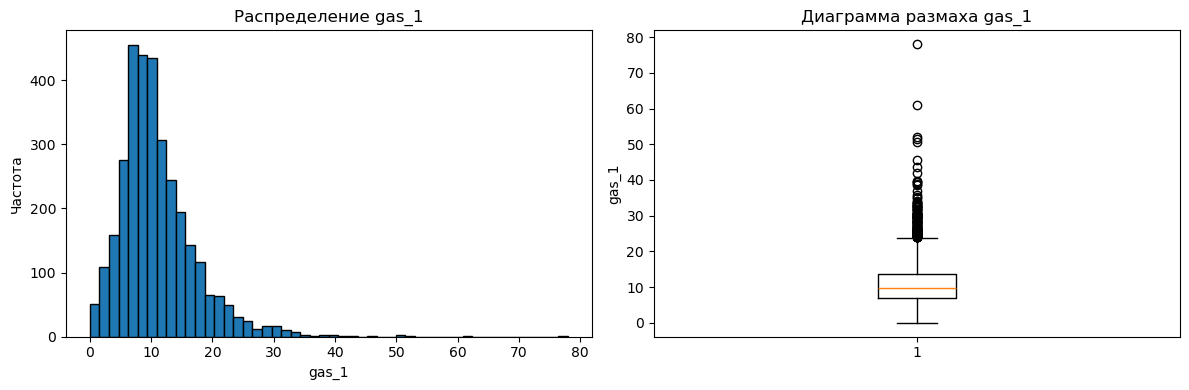


Топ-10 максимальных значений gas_1:


,key,gas_1
319,322,77.995040
277,280,60.935689
2107,2110,52.142373
2567,2570,51.380229
116,117,50.581035
2105,2108,45.638999
1461,1464,43.655411
660,663,41.854643
525,528,39.728826
610,613,39.425706



Топ-10 минимальных значений gas_1:


,key,gas_1
863,866,0.008399
1044,1047,0.016696
2100,2103,0.263029
2353,2356,0.275081
352,355,0.325733
2466,2469,0.335164
2680,2683,0.338997
951,954,0.364256
1130,1133,0.364789
193,195,0.374436



Число проблемных строк: 0

Описание итогового признака gas_1:


,gas_1
count,3239.000000
mean,11.002062
std,6.220327
min,0.008399
1%,1.132655
5%,3.196835
50%,9.836267
95%,22.626203
99%,31.558630
max,77.995040



Пример подготовленных данных gas:


,key,gas_1
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692



После очистки осталось 3239 строк из 3239
Уникальных партий в gas_agg: 3239


In [11]:
# таблица gas: анализ и подготовка
gas_df = dfs['gas'].copy()

# переименование признака
gas_df = gas_df.rename(columns={'Газ 1': 'gas_1'})

# приведение типов
gas_df['gas_1'] = pd.to_numeric(gas_df['gas_1'], errors='coerce')

# контроль качества
gas_quality = pd.Series({
    'Всего строк': len(gas_df),
    'Дубликаты key': int(gas_df['key'].duplicated().sum()),
    'Пропуски в gas_1': int(gas_df['gas_1'].isna().sum()),
    'Отрицательные значения gas_1': int((gas_df['gas_1'] < 0).sum()),
    'Нулевые значения gas_1': int((gas_df['gas_1'] == 0).sum()),
    'Уникальных key': int(gas_df['key'].nunique()),
    'key вне bulk': int((~gas_df['key'].isin(bulk_df['key'])).sum()),
    'key вне arc': int((~gas_df['key'].isin(arc_df['key'])).sum()),
}, name='Значение')

print('Контроль качества таблицы gas:')
display(gas_quality.to_frame())

print('\nОписание признака gas_1:')
display(
    gas_df[['gas_1']].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
)

# визуализация распределения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(gas_df['gas_1'].dropna(), bins=50, edgecolor='black')
axes[0].set_title('Распределение gas_1')
axes[0].set_xlabel('gas_1')
axes[0].set_ylabel('Частота')

axes[1].boxplot(gas_df['gas_1'].dropna(), vert=True)
axes[1].set_title('Диаграмма размаха gas_1')
axes[1].set_ylabel('gas_1')

plt.tight_layout()
save_plot('gas_1_distribution')
plt.show()

print('\nТоп-10 максимальных значений gas_1:')
display(gas_df.sort_values('gas_1', ascending=False).head(10))

print('\nТоп-10 минимальных значений gas_1:')
display(gas_df.sort_values('gas_1').head(10))

# проблемные строки
bad_gas_na = gas_df['gas_1'].isna()
bad_gas_neg = gas_df['gas_1'] < 0
bad_gas_any = bad_gas_na | bad_gas_neg

print(f'\nЧисло проблемных строк: {bad_gas_any.sum()}')
if bad_gas_any.sum() > 0:
    display(gas_df.loc[bad_gas_any])

# очищенная версия
gas_df_clean = gas_df.loc[~bad_gas_any].copy()

# итоговая таблица для объединения
gas_agg = gas_df_clean[['key', 'gas_1']].copy()

print('\nОписание итогового признака gas_1:')
display(
    gas_agg[['gas_1']].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
)

print('\nПример подготовленных данных gas:')
display(gas_agg.head())

print(f'\nПосле очистки осталось {gas_df_clean.shape[0]} строк из {gas_df.shape[0]}')
print(f'Уникальных партий в gas_agg: {gas_agg["key"].nunique()}')

Проверка таблицы `gas` показала, что она имеет простую и устойчивую структуру: каждая партия представлена одной строкой, дубликаты по `key` отсутствуют, пропуски, нулевые и отрицательные значения не обнаружены.

Распределение признака `gas_1` имеет выраженную правостороннюю асимметрию. Основная часть наблюдений сосредоточена примерно в диапазоне от 5 до 15, медианное значение составляет 9.84, а отдельные крупные значения достигают 77.99. Диаграмма размаха показывает наличие верхних выбросов, однако для технологических данных такая картина выглядит естественной и сама по себе не свидетельствует об ошибке.

Дополнительно видно, что таблица `gas` покрывает больше партий, чем `bulk` и `arc`: часть партий присутствует в таблице газа, но отсутствует в других источниках. Это ещё раз подтверждает, что при последующем объединении данных нужно аккуратно выбирать базовую таблицу и не использовать без необходимости жёсткое пересечение всех источников.

Таким образом, таблица `gas` не требует сложной предобработки. Признак `gas_1` можно напрямую использовать при формировании итогового датасета.

### Таблица `temp`

Таблица `temp` является ключевой для проекта, поскольку именно на её основе будет сформирован целевой признак. Для одной партии здесь может содержаться несколько измерений температуры, выполненных на разных этапах обработки.

На этом этапе необходимо определить, какие партии подходят для моделирования, и сформировать температурные признаки: начальную температуру партии, финальную температуру и количество валидных измерений.

Для таблицы `temp` важно проверить корректность временных признаков, распределение пропусков и число валидных измерений температуры по каждой партии. Это позволит корректно сформировать итоговую выборку для модели.

Контроль качества таблицы temp:


,Значение
Всего строк,18092
Пропуски во времени,0
Пропуски в temperature,3427
"Дубликаты (key, measure_time)",0
Уникальных key,3216
Отрицательные temperature,0
Нереалистичные temperature (< 1400 или > 1800),5



Описание признака temperature:


,temperature
count,14665.000000
mean,1590.722741
std,20.394381
min,1191.000000
1%,1545.000000
5%,1562.000000
25%,1580.000000
50%,1590.000000
75%,1599.000000
95%,1623.000000



Удалено нереалистичных измерений температуры (< 1400 или > 1800): 5

Описание числа валидных измерений температуры по партиям:


...


Распределение числа валидных измерений температуры по партиям:


,count
temp_count,
1,740
2,33
3,136
4,394
5,689
6,579
7,389
8,151
9,66



Партии с хотя бы одним валидным измерением:  3215
Партии с минимум двумя валидными измерениями: 2475
Отфильтровано партий:                         740

Описание итоговых температурных признаков:


,first_temp,mean_temp,min_temp,max_temp,target_temp,temp_delta,temp_count,temp_span_sec
count,2475.000000,2475.000000,2475.000000,2475.000000,2475.000000,2475.000000,2475.000000,2475.000000
mean,1589.029899,1591.608416,1578.803636,1603.154747,1595.336162,6.306263,5.624242,2279.871111
std,24.998058,16.339790,18.386937,18.490922,16.023153,23.058569,1.610965,1373.958293
min,1519.000000,1547.000000,1515.000000,1558.000000,1541.000000,-98.000000,2.000000,270.000000
1%,1533.000000,1559.948000,1532.000000,1574.000000,1570.000000,-52.000000,2.000000,668.180000
5%,1550.000000,1569.285714,1548.000000,1580.000000,1576.000000,-32.000000,3.000000,990.000000
50%,1588.000000,1589.833333,1579.000000,1599.000000,1593.000000,7.000000,5.000000,2006.000000
95%,1633.000000,1618.922222,1606.000000,1640.000000,1621.000000,43.000000,8.000000,4092.500000
99%,1651.260000,1650.130000,1638.260000,1668.260000,1661.260000,57.000000,10.000000,6911.340000
max,1679.000000,1681.800000,1661.000000,1705.000000,1700.000000,105.000000,17.000000,23674.000000


Saved: ../images/target_temp_distribution.png


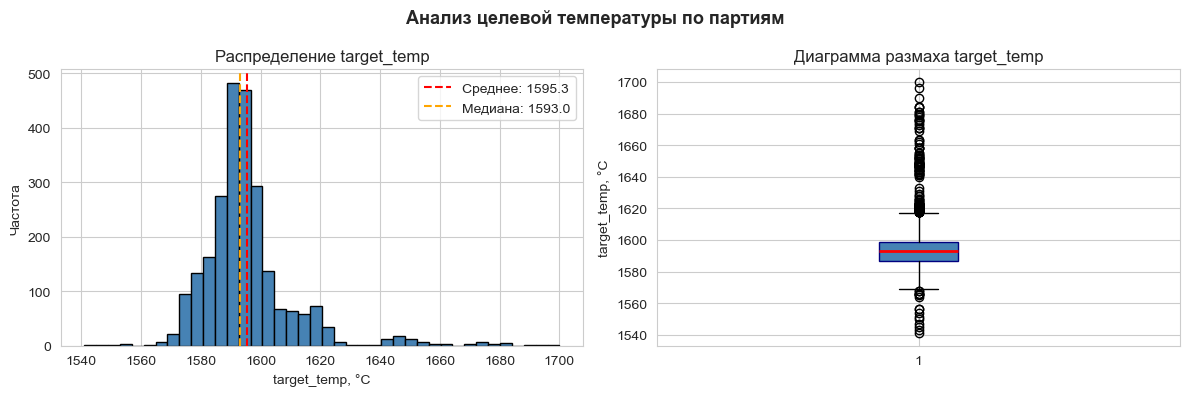


Пример подготовленных данных temp:


,key,first_measure_time,last_measure_time,first_temp,mean_temp,min_temp,max_temp,target_temp,temp_count,temp_span_sec,temp_delta
0,1,2019-05-03 11:02:04,2019-05-03 11:30:38,1571.0,1602.166667,1571.0,1618.0,1613.0,6,1714.0,42.0
1,2,2019-05-03 11:34:04,2019-05-03 11:55:09,1581.0,1590.600000,1577.0,1604.0,1602.0,5,1265.0,21.0
2,3,2019-05-03 12:06:44,2019-05-03 12:35:57,1596.0,1598.166667,1596.0,1600.0,1599.0,6,1753.0,3.0
3,4,2019-05-03 12:39:27,2019-05-03 12:59:47,1601.0,1616.800000,1601.0,1625.0,1625.0,5,1220.0,24.0
4,5,2019-05-03 13:11:03,2019-05-03 13:36:39,1576.0,1589.000000,1576.0,1602.0,1602.0,5,1536.0,26.0


In [31]:
# таблица temp: анализ и подготовка
temp_df = dfs['temp'].copy()

# переименование признаков
temp_df = temp_df.rename(columns={
	'Время замера': 'measure_time',
	'Температура': 'temperature'
})

# приведение типов
temp_df['measure_time'] = pd.to_datetime(temp_df['measure_time'], errors='coerce')
temp_df['temperature'] = pd.to_numeric(temp_df['temperature'], errors='coerce')

# контроль качества
temp_quality = pd.Series({
	'Всего строк': len(temp_df),
	'Пропуски во времени': int(temp_df['measure_time'].isna().sum()),
	'Пропуски в temperature': int(temp_df['temperature'].isna().sum()),
	'Дубликаты (key, measure_time)': int(temp_df.duplicated(subset=['key', 'measure_time']).sum()),
	'Уникальных key': int(temp_df['key'].nunique()),
	'Отрицательные temperature': int((temp_df['temperature'] < 0).sum()),
	'Нереалистичные temperature (< 1400 или > 1800)': int(
		((temp_df['temperature'] < 1400) | (temp_df['temperature'] > 1800)).sum()
	),
}, name='Значение')

print('Контроль качества таблицы temp:')
display(temp_quality.to_frame())

print('\nОписание признака temperature:')
display(
	temp_df[['temperature']].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
)

# строки с валидной температурой и временем
temp_valid = temp_df.dropna(subset=['temperature', 'measure_time']).copy()

# удаление нереалистичных измерений — супер-выбросы по условию задачи
n_unrealistic = ((temp_valid['temperature'] < 1400) | (temp_valid['temperature'] > 1800)).sum()
temp_valid = temp_valid[
    (temp_valid['temperature'] >= 1400) & (temp_valid['temperature'] <= 1800)
].copy()
print(f'\nУдалено нереалистичных измерений температуры (< 1400 или > 1800): {n_unrealistic}')

temp_valid = temp_valid.sort_values(['key', 'measure_time']).reset_index(drop=True)

# число валидных измерений по партии
temp_counts = (
	temp_valid.groupby('key')
	.size()
	.rename('temp_count')
	.reset_index()
)

print('\nОписание числа валидных измерений температуры по партиям:')
display(
	temp_counts[['temp_count']].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
)

print('\nРаспределение числа валидных измерений температуры по партиям:')
display(temp_counts['temp_count'].value_counts().sort_index().to_frame())

# партии, пригодные для моделирования (минимум 2 валидных измерения)
valid_keys = temp_counts.loc[temp_counts['temp_count'] >= 2, 'key']

print(f'\nПартии с хотя бы одним валидным измерением:  {temp_counts["key"].nunique()}')
print(f'Партии с минимум двумя валидными измерениями: {valid_keys.nunique()}')
print(f'Отфильтровано партий:                         {temp_counts["key"].nunique() - valid_keys.nunique()}')

temp_model = temp_valid[temp_valid['key'].isin(valid_keys)].copy()

# формирование температурных признаков по партии
temp_agg = (
	temp_model.groupby('key')
	.agg(
		first_measure_time=('measure_time', 'first'),
		last_measure_time=('measure_time', 'last'),
		first_temp=('temperature', 'first'),
		mean_temp=('temperature', 'mean'),
		min_temp=('temperature', 'min'),
		max_temp=('temperature', 'max'),
		target_temp=('temperature', 'last'),
		temp_count=('temperature', 'count')
	)
	.reset_index()
)

temp_agg['temp_span_sec'] = (
	temp_agg['last_measure_time'] - temp_agg['first_measure_time']
).dt.total_seconds()

temp_agg['temp_delta'] = temp_agg['target_temp'] - temp_agg['first_temp']

print('\nОписание итоговых температурных признаков:')
display(
	temp_agg[['first_temp', 'mean_temp', 'min_temp', 'max_temp', 'target_temp', 'temp_delta', 'temp_count', 'temp_span_sec']]
	.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
)

# визуализация target_temp
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(temp_agg['target_temp'].dropna(), bins=40, edgecolor='black', color='steelblue')
axes[0].set_title('Распределение target_temp')
axes[0].set_xlabel('target_temp, °C')
axes[0].set_ylabel('Частота')
axes[0].axvline(temp_agg['target_temp'].mean(), color='red', linestyle='--', label=f'Среднее: {temp_agg["target_temp"].mean():.1f}')
axes[0].axvline(temp_agg['target_temp'].median(), color='orange', linestyle='--', label=f'Медиана: {temp_agg["target_temp"].median():.1f}')
axes[0].legend()

axes[1].boxplot(temp_agg['target_temp'].dropna(), vert=True, patch_artist=True,
				boxprops=dict(facecolor='steelblue', color='navy'),
				medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Диаграмма размаха target_temp')
axes[1].set_ylabel('target_temp, °C')

plt.suptitle('Анализ целевой температуры по партиям', fontsize=13, fontweight='bold')
plt.tight_layout()
save_plot('target_temp_distribution')
plt.show()

print('\nПример подготовленных данных temp:')
display(temp_agg.head())

Проверка таблицы `temp` показала, что именно она задаёт основу для построения целевого признака. Пропусков во времени измерения не обнаружено, дубликаты по сочетанию `key` и `measure_time` отсутствуют. При этом в столбце `temperature` содержится 3427 пропусков, поэтому для дальнейшего анализа были оставлены только строки с валидными значениями температуры и времени.

Всего хотя бы одно валидное измерение температуры есть у 3216 партий. Однако для построения модели этого недостаточно: чтобы задать и исходную, и финальную температуру, партии должны содержать как минимум два валидных измерения. После такого отбора осталось 2475 партий, а 741 партия была исключена из дальнейшего моделирования.

Распределение числа валидных измерений показывает, что чаще всего на одну партию приходится от 4 до 6 температурных замеров, медианное значение равно 5. Это хорошо согласуется с логикой технологического процесса, в котором температура измеряется несколько раз на разных этапах обработки.

После сортировки измерений по времени по каждой партии были сформированы основные температурные признаки:
- `first_temp` — первая валидная температура;
- `target_temp` — последняя валидная температура;
- `temp_count` — число валидных измерений;
- `temp_span_sec` — интервал между первым и последним измерением.

Дополнительно были рассчитаны аналитические характеристики температурного профиля партии: `mean_temp`, `min_temp`, `max_temp` и `temp_delta`. Они полезны для понимания поведения данных, однако при построении модели необходимо внимательно контролировать их использование, чтобы не допустить утечки информации о целевой переменной.

Распределение `target_temp` близко к одновершинному и сосредоточено в основном в районе 1580–1600 °C. Среднее значение составляет 1595.3 °C, медиана — 1593.0 °C. На диаграмме размаха заметны отдельные выбросы, однако в целом распределение выглядит рабочим и пригодным для решения задачи регрессии.

**Вывод:** таблица `temp` успешно подготовлена для формирования целевого признака. В итоговую выборку включены только партии с минимум двумя валидными измерениями температуры, что позволяет корректно задать как исходную температуру, так и финальную температуру партии.

### Таблицы `wire` и `wire_time`

Таблицы `wire` и `wire_time` рассматриваю совместно, поскольку они описывают один и тот же этап обработки партии. Первая таблица содержит объёмы проволочных материалов, вторая — время их подачи. Такой подход позволяет проанализировать как состав добавок, так и временные особенности их внесения в процессе обработки стали.

Для этих таблиц важно проверить согласованность структуры, природу пропусков и частоту использования разных типов проволочных материалов. Это позволит определить, какие признаки следует использовать напрямую, а какие лучше агрегировать.

In [13]:
# таблицы wire и wire_time: анализ и подготовка (улучшенная версия)
wire_df = dfs['wire'].copy()
wire_time_df = dfs['wire_time'].copy()

# признаки материалов
wire_cols = sorted([c for c in wire_df.columns if c != 'key'])
wire_time_cols = sorted([c for c in wire_time_df.columns if c != 'key'])

# проверка структуры
same_col_set = set(wire_df.columns) == set(wire_time_df.columns)
same_material_cols = wire_cols == wire_time_cols

print('Совпадают ли наборы столбцов:', same_col_set)
print('Совпадают ли списки material-колонок:', same_material_cols)
print()

if not same_col_set:
	print('⚠️ ВНИМАНИЕ: структура wire и wire_time отличается. Работаем по пересечению material-колонок.')
	common_material_cols = sorted(set(wire_cols).intersection(wire_time_cols))
else:
	common_material_cols = wire_cols.copy()

# унификация порядка колонок
wire_cols = common_material_cols
wire_time_cols = common_material_cols
wire_df = wire_df[['key'] + wire_cols]
wire_time_df = wire_time_df[['key'] + wire_time_cols]

# приведение типов
wire_df[wire_cols] = wire_df[wire_cols].apply(pd.to_numeric, errors='coerce')
for col in wire_time_cols:
	wire_time_df[col] = pd.to_datetime(wire_time_df[col], errors='coerce')

# контроль ключей и дублей
print('Дубликаты key в wire:', wire_df['key'].duplicated().sum())
print('Дубликаты key в wire_time:', wire_time_df['key'].duplicated().sum())
print('Уникальных key в wire:', wire_df['key'].nunique())
print('Уникальных key в wire_time:', wire_time_df['key'].nunique())
print('key только в wire:', wire_df.loc[~wire_df['key'].isin(wire_time_df['key']), 'key'].nunique())
print('key только в wire_time:', wire_time_df.loc[~wire_time_df['key'].isin(wire_df['key']), 'key'].nunique())
print()

# согласованность пропусков
wire_na_mask = wire_df.set_index('key')[wire_cols].sort_index().isna()
wire_time_na_mask = wire_time_df.set_index('key')[wire_time_cols].sort_index().isna()

common_keys = wire_na_mask.index.intersection(wire_time_na_mask.index)
same_missing_mask = wire_na_mask.loc[common_keys].equals(wire_time_na_mask.loc[common_keys])

print('Совпадает ли структура пропусков wire и wire_time (по общим key):', same_missing_mask)
if not same_missing_mask:
	mismatch_cells = (wire_na_mask.loc[common_keys] != wire_time_na_mask.loc[common_keys]).sum().sum()
	print(f'Несовпадающих ячеек маски пропусков: {int(mismatch_cells)}')
print()

# базовая статистика заполненности
wire_non_null = wire_df[wire_cols].notna().sum().sort_values(ascending=False)
wire_time_non_null = wire_time_df[wire_time_cols].notna().sum().sort_values(ascending=False)

print('Число непустых значений по wire-признакам:')
display(wire_non_null.to_frame(name='non_null_count'))

print('Число непустых временных значений по wire_time-признакам:')
display(wire_time_non_null.to_frame(name='non_null_count'))

# контроль аномалий в объемах
neg_count = int((wire_df[wire_cols] < 0).sum().sum())
print(f'Отрицательных значений в wire-признаках: {neg_count}')
print()

# агрегация wire по key
wire_agg = wire_df.groupby('key', as_index=False)[wire_cols].sum(min_count=1)
wire_agg[wire_cols] = wire_agg[wire_cols].fillna(0)

wire_agg['wire_total'] = wire_agg[wire_cols].sum(axis=1)
wire_agg['wire_types_used'] = (wire_agg[wire_cols] > 0).sum(axis=1)
wire_agg['wire_max_single'] = wire_agg[wire_cols].max(axis=1)

print('Описание агрегированных признаков wire:')
display(
	wire_agg[['wire_total', 'wire_types_used', 'wire_max_single']]
	.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
)

# агрегация временных признаков wire_time по key
wire_time_long = (
	wire_time_df
	.set_index('key')[wire_time_cols]
	.stack(dropna=True)
	.rename('event_time')
	.reset_index()
)

wire_time_features = (
	wire_time_long.groupby('key', as_index=False)
	.agg(
		wire_time_first=('event_time', 'min'),
		wire_time_last=('event_time', 'max'),
		wire_time_count=('event_time', 'count')
	)
)

wire_time_features['wire_time_span_sec'] = (
	wire_time_features['wire_time_last'] - wire_time_features['wire_time_first']
).dt.total_seconds()

# ключи без wire_time-событий (берем union ключей для надежности)
all_wire_keys = pd.DataFrame({
	'key': sorted(set(wire_df['key']).union(set(wire_time_df['key'])))
})

wire_time_features = all_wire_keys.merge(wire_time_features, on='key', how='left')
wire_time_features['wire_time_count'] = wire_time_features['wire_time_count'].fillna(0).astype(int)
wire_time_features['wire_time_span_sec'] = wire_time_features['wire_time_span_sec'].fillna(0)

print('Описание временных признаков wire_time:')
display(
	wire_time_features[['wire_time_count', 'wire_time_span_sec']]
	.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
)

print('Топ материалов по частоте использования:')
display(wire_non_null.head(10))

print('Пример подготовленных данных wire:')
display(wire_agg[['key', 'wire_total', 'wire_types_used', 'wire_max_single'] + wire_cols[:5]].head())

print('Пример подготовленных данных wire_time:')
display(wire_time_features.head())

Совпадают ли наборы столбцов: True
Совпадают ли списки material-колонок: True

Дубликаты key в wire: 0
Дубликаты key в wire_time: 0
Уникальных key в wire: 3081
Уникальных key в wire_time: 3081
key только в wire: 0
key только в wire_time: 0

Совпадает ли структура пропусков wire и wire_time (по общим key): True

Число непустых значений по wire-признакам:


,non_null_count
Wire 1,3055
Wire 2,1079
Wire 6,73
Wire 3,63
Wire 9,29
Wire 8,19
Wire 4,14
Wire 7,11
Wire 5,1


Число непустых временных значений по wire_time-признакам:


,non_null_count
Wire 1,3055
Wire 2,1079
Wire 6,73
Wire 3,63
Wire 9,29
Wire 8,19
Wire 4,14
Wire 7,11
Wire 5,1


Отрицательных значений в wire-признаках: 0

Описание агрегированных признаков wire:


...

Wire 1    3055
Wire 2    1079
Wire 6      73
Wire 3      63
Wire 9      29
Wire 8      19
Wire 4      14
Wire 7      11
Wire 5       1
dtype: int64

Пример подготовленных данных wire:


,key,wire_total,wire_types_used,wire_max_single,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5
0,1,60.059998,1,60.059998,60.059998,0.00000,0.0,0.0,0.0
1,2,96.052315,1,96.052315,96.052315,0.00000,0.0,0.0,0.0
2,3,91.160157,1,91.160157,91.160157,0.00000,0.0,0.0,0.0
3,4,89.063515,1,89.063515,89.063515,0.00000,0.0,0.0,0.0
4,5,98.352796,2,89.238236,89.238236,9.11456,0.0,0.0,0.0


Пример подготовленных данных wire_time:


,key,wire_time_first,wire_time_last,wire_time_count,wire_time_span_sec
0,1,2019-05-03 11:06:19,2019-05-03 11:06:19,1,0.0
1,2,2019-05-03 11:36:50,2019-05-03 11:36:50,1,0.0
2,3,2019-05-03 12:11:46,2019-05-03 12:11:46,1,0.0
3,4,2019-05-03 12:43:22,2019-05-03 12:43:22,1,0.0
4,5,2019-05-03 13:15:34,2019-05-03 13:20:44,2,310.0


Анализ таблиц `wire` и `wire_time` показал, что они полностью согласованы между собой: наборы признаков совпадают, дубликаты по `key` отсутствуют, а состав партий в обеих таблицах одинаковый.

Структура пропусков в `wire` и `wire_time` также полностью совпадает, что подтверждает технологическую интерпретацию: отсутствие значения, как правило, означает отсутствие подачи соответствующего проволочного материала, а не потерю данных. Проверка показала, что отрицательные значения объёмов отсутствуют.

Наиболее часто используется `Wire 1`: он присутствует почти во всех партиях этой группы. Значительно реже встречается `Wire 2`, а остальные типы проволочных материалов используются эпизодически. Это указывает на то, что вклад разных проволочных добавок в итоговую модель будет неодинаковым.

После заполнения пропусков нулями по каждой партии были сформированы агрегированные признаки: суммарный объём проволочных материалов (`wire_total`), количество использованных типов (`wire_types_used`) и максимальный объём одной проволочной добавки (`wire_max_single`). В среднем на одну партию приходится около 124 единиц проволочных материалов, при этом чаще всего используется только один тип проволоки.

Из таблицы `wire_time` были выделены агрегированные временные характеристики: время первой подачи, время последней подачи, количество событий подачи и временной интервал между первой и последней подачей. Медианное число событий подачи равно 1, а медианный временной интервал равен 0 секунд, что указывает на то, что для большинства партий проволока вносится однократно.

Таким образом, таблицы `wire` и `wire_time` подготовлены к дальнейшему объединению с другими источниками данных.

**Вывод:** таблицы `wire` и `wire_time` имеют хорошее качество и полностью согласованы между собой. После интерпретации пропусков как отсутствия подачи материалов эти данные можно использовать для формирования признаков итогового датасета.

## Формирование целевого признака и агрегация данных

Ключевой для проекта является таблица с измерениями температуры. Для одной партии в ней может содержаться несколько замеров, соответствующих разным этапам обработки.

Целевым признаком выбрана последняя измеренная температура партии, поскольку именно она отражает итоговое состояние сплава после завершения технологического процесса.

Первая измеренная температура партии будет использована как один из входных признаков, так как она характеризует исходное состояние расплава перед дальнейшей обработкой.

В итоговую выборку включаются только те партии, для которых доступны как минимум два валидных измерения температуры.

### Агрегация признаков по партиям

Поскольку во многих таблицах одна партия представлена несколькими строками, перед объединением данные необходимо агрегировать по `key`.

Цель агрегации — получить итоговый датасет в формате одна строка на одну партию, пригодный для анализа и обучения моделей.

In [14]:
# агрегация признаков arc по партии
arc_agg = (
    arc_df_clean.groupby('key', as_index=False)
    .agg(
        heating_duration_total=('heating_time_sec', 'sum'),
        heating_cycles=('heating_time_sec', 'count'),
        active_power_mean=('Активная мощность', 'mean'),
        reactive_power_mean=('Реактивная мощность', 'mean'),
        energy_active_total=('energy_active', 'sum'),
        energy_full_total=('energy_full', 'sum'),
    )
)

print(f'Уникальных партий в arc_agg: {arc_agg["key"].nunique()}')
print('\nОписание агрегированных признаков arc:')
display(
    arc_agg.drop(columns='key')
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
)

print('\nПример подготовленных данных arc (агрегировано по key):')
display(arc_agg.head())

Уникальных партий в arc_agg: 3213

Описание агрегированных признаков arc:


,heating_duration_total,heating_cycles,active_power_mean,reactive_power_mean,energy_active_total,energy_full_total
count,3213.000000,3213.000000,3213.000000,3213.000000,3213.000000,3213.000000
mean,794.691566,4.628696,0.661332,0.485966,527.928285,655.688884
std,332.439136,1.608860,0.128392,0.097600,248.751648,308.950188
min,57.000000,1.000000,0.267676,0.196228,26.187544,33.430208
1%,163.600000,1.000000,0.399939,0.289873,91.227987,112.700854
5%,309.600000,2.000000,0.465357,0.337241,180.053355,223.476544
50%,770.000000,4.000000,0.652864,0.481626,498.897459,620.111140
95%,1356.400000,7.000000,0.889807,0.660331,959.469616,1191.815951
99%,1744.560000,9.000000,0.997171,0.749806,1220.186209,1528.269563
max,4189.000000,16.000000,1.243889,0.960763,3718.054401,4546.405812



Пример подготовленных данных arc (агрегировано по key):


,key,heating_duration_total,heating_cycles,active_power_mean,reactive_power_mean,energy_active_total,energy_full_total
0,1,1098.0,5,0.607346,0.428564,628.616930,770.282114
1,2,811.0,4,0.534852,0.363339,395.281800,481.760005
2,3,655.0,5,0.812728,0.587491,581.774624,722.837668
3,4,741.0,4,0.676622,0.514248,543.710274,683.455597
4,5,869.0,4,0.563238,0.421998,412.180480,512.169934


Агрегация таблицы `arc` по номеру партии выполнена. По каждой партии сформированы суммарная длительность нагрева, количество циклов нагрева, средние значения мощности, а также суммарная энергия нагрева по активной и полной мощности.

Эти признаки отражают интенсивность и объём работы электродов и будут использованы в итоговом датасете.

## Объединение данных

После подготовки отдельных таблиц объединяю агрегированные признаки в единый датасет по номеру партии `key`.

На этом этапе важно сохранить только те признаки, которые действительно могут быть полезны для моделирования, и избежать неоправданной потери наблюдений при объединении таблиц.

In [15]:
# объединение всех агрегированных таблиц в единый датасет

# обязательное требование: в итоговый датасет включаем только те партии,
# которые присутствуют во ВСЕХ семи исходных таблицах
common_keys = (
    set(dfs['temp']['key'])
    & set(dfs['arc']['key'])
    & set(dfs['bulk']['key'])
    & set(dfs['bulk_time']['key'])
    & set(dfs['wire']['key'])
    & set(dfs['wire_time']['key'])
    & set(dfs['gas']['key'])
)
print(f'Ключей в пересечении всех таблиц: {len(common_keys)}')

# базой служит temp_agg — только партии с минимум двумя валидными измерениями температуры,
# дополнительно фильтруем до common_keys
# из temp_agg берём только признаки без утечки: first_temp, target_temp, temp_span_sec
temp_features = temp_agg[
    temp_agg['key'].isin(common_keys)
][['key', 'first_temp', 'target_temp', 'temp_span_sec']].copy()

print(f'Партий после фильтрации по common_keys: {len(temp_features)}')

df = (
    temp_features
    .merge(arc_agg, on='key', how='left')
    .merge(
        bulk_agg[['key'] + bulk_cols + ['bulk_total', 'bulk_types_used', 'bulk_max_single']],
        on='key', how='left'
    )
    .merge(
        bulk_time_features[['key', 'bulk_time_span_sec', 'bulk_time_count']],
        on='key', how='left'
    )
    .merge(
        wire_agg[['key'] + wire_cols + ['wire_total', 'wire_types_used', 'wire_max_single']],
        on='key', how='left'
    )
    .merge(
        wire_time_features[['key', 'wire_time_span_sec', 'wire_time_count']],
        on='key', how='left'
    )
    .merge(gas_agg[['key', 'gas_1']], on='key', how='left')
)

# bulk и wire: пропуски означают отсутствие добавки → заполняем нулями
bulk_wire_fill_cols = (
    bulk_cols + wire_cols
    + ['bulk_total', 'bulk_types_used', 'bulk_max_single',
       'wire_total', 'wire_types_used', 'wire_max_single',
       'bulk_time_span_sec', 'bulk_time_count',
       'wire_time_span_sec', 'wire_time_count']
)
df[bulk_wire_fill_cols] = df[bulk_wire_fill_cols].fillna(0)

print(f'Размер объединённого датасета: {df.shape}')
print(f'Уникальных партий: {df["key"].nunique()}')

print('\nПропуски по признакам после объединения:')
missing = df.isna().sum()
missing_nonzero = missing[missing > 0]
if len(missing_nonzero) > 0:
    display(missing_nonzero.to_frame(name='пропусков').assign(
        процент=lambda x: (x['пропусков'] / len(df) * 100).round(2)
    ))
else:
    print('Пропусков нет.')

print('\nПервые строки объединённого датасета:')
display(df.head())

Ключей в пересечении всех таблиц: 3022
Партий после фильтрации по common_keys: 2329
Размер объединённого датасета: (2329, 45)
Уникальных партий: 2329

Пропуски по признакам после объединения:


,пропусков,процент
heating_duration_total,1,0.04
heating_cycles,1,0.04
active_power_mean,1,0.04
reactive_power_mean,1,0.04
energy_active_total,1,0.04
energy_full_total,1,0.04



Первые строки объединённого датасета:


,key,first_temp,target_temp,temp_span_sec,heating_duration_total,heating_cycles,active_power_mean,reactive_power_mean,energy_active_total,energy_full_total,Bulk 1,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,bulk_total,bulk_types_used,bulk_max_single,bulk_time_span_sec,bulk_time_count,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9,wire_total,wire_types_used,wire_max_single,wire_time_span_sec,wire_time_count,gas_1
0,1,1571.0,1613.0,1714.0,1098.0,5.0,0.607346,0.428564,628.616930,770.282114,0.0,0.0,0.0,206.0,0.0,150.0,154.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,553.0,4,206.0,1085.0,4,60.059998,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.059998,1,60.059998,0.0,1,29.749986
1,2,1581.0,1602.0,1265.0,811.0,4.0,0.534852,0.363339,395.281800,481.760005,0.0,0.0,0.0,206.0,0.0,149.0,154.0,0.0,0.0,73.0,0.0,0.0,0.0,0.0,0.0,582.0,4,206.0,1000.0,4,96.052315,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,96.052315,1,96.052315,0.0,1,12.555561
2,3,1596.0,1599.0,1753.0,655.0,5.0,0.812728,0.587491,581.774624,722.837668,0.0,0.0,0.0,205.0,0.0,152.0,153.0,0.0,0.0,34.0,0.0,0.0,0.0,0.0,0.0,544.0,4,205.0,983.0,4,91.160157,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,91.160157,1,91.160157,0.0,1,28.554793
3,4,1601.0,1625.0,1220.0,741.0,4.0,0.676622,0.514248,543.710274,683.455597,0.0,0.0,0.0,207.0,0.0,153.0,154.0,0.0,0.0,81.0,0.0,0.0,0.0,0.0,0.0,595.0,4,207.0,878.0,4,89.063515,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,89.063515,1,89.063515,0.0,1,18.841219
4,5,1576.0,1602.0,1536.0,869.0,4.0,0.563238,0.421998,412.180480,512.169934,0.0,0.0,0.0,203.0,0.0,151.0,152.0,0.0,0.0,78.0,0.0,0.0,0.0,0.0,0.0,584.0,4,203.0,205.0,4,89.238236,9.11456,0.0,0.0,0.0,0.0,0.0,0.0,0.0,98.352796,2,89.238236,310.0,2,5.413692


Объединение выполнено на основе таблицы температур: в итоговый датасет вошли только партии с минимум двумя валидными измерениями температуры.

Пропуски в признаках материалов (`bulk`, `wire`) интерпретированы как отсутствие подачи и заполнены нулями. Пропуски в признаках из таблиц `arc` и `gas` связаны с тем, что не все партии представлены во всех источниках данных — это ожидаемое поведение.

**Защита от утечки данных.** При агрегации таблицы `temp` были рассчитаны вспомогательные признаки `temp_delta`, `mean_temp`, `min_temp`, `max_temp`. Они использовались исключительно для анализа в EDA и в обучение **не включались**: все они производны от финальной температуры и их наличие в признаках создавало бы прямую утечку целевой переменной.

**Признак `temp_span_sec`** — время между первым и последним измерением температуры — является характеристикой длительности цикла обработки партии. Он включён в модель, поскольку по технологической логике этот интервал отражает общую продолжительность процесса, которая потенциально влияет на конечную температуру. При необходимости более строгой схемы этот признак можно исключить без потери смысловой полноты модели.

## Анализ объединённого датасета

После объединения всех подготовленных таблиц проанализируем итоговый датасет.

На этом этапе посмотрим, какой получилась итоговая выборка, есть ли пропуски после объединения, как распределены признаки и целевая переменная, а также проверим возможные выбросы и связи между признаками. Это покажет, насколько данные готовы к обучению моделей и какие признаки действительно стоит оставить в работе.

In [16]:
# базовая информация об объединённом датасете
print('Информация об объединённом датасете:')
df.info()

print('\nОписательная статистика:')
display(
    df.drop(columns='key').describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
)

Информация об объединённом датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2329 entries, 0 to 2328
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   key                     2329 non-null   int64  
 1   first_temp              2329 non-null   float64
 2   target_temp             2329 non-null   float64
 3   temp_span_sec           2329 non-null   float64
 4   heating_duration_total  2328 non-null   float64
 5   heating_cycles          2328 non-null   float64
 6   active_power_mean       2328 non-null   float64
 7   reactive_power_mean     2328 non-null   float64
 8   energy_active_total     2328 non-null   float64
 9   energy_full_total       2328 non-null   float64
 10  Bulk 1                  2329 non-null   float64
 11  Bulk 10                 2329 non-null   float64
 12  Bulk 11                 2329 non-null   float64
 13  Bulk 12                 2329 non-null   float64
 14  Bul

,first_temp,target_temp,temp_span_sec,heating_duration_total,heating_cycles,active_power_mean,reactive_power_mean,energy_active_total,energy_full_total,Bulk 1,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,bulk_total,bulk_types_used,bulk_max_single,bulk_time_span_sec,bulk_time_count,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9,wire_total,wire_types_used,wire_max_single,wire_time_span_sec,wire_time_count,gas_1
count,2329.000000,2329.000000,2329.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.0,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000
mean,1587.386003,1593.365393,2321.810219,807.808419,4.695876,0.664104,0.488890,539.107742,669.912912,3.427651,5.052812,4.245170,208.415629,1.067411,153.853585,119.952769,1.422499,47.348218,37.303564,2.640189,22.430228,2.004723,0.021039,0.444826,609.630313,3.592958,259.043796,985.905968,3.592958,102.443601,17.609859,3.234916,0.306550,0.0,0.978820,0.006361,0.311311,0.317113,125.208530,1.397166,107.165353,209.708459,1.397166,11.375600
std,23.619841,11.200915,1385.191527,340.823100,1.606909,0.128377,0.097967,257.280972,319.493496,12.412132,20.917800,22.515487,157.062272,14.235055,81.404354,84.640443,19.082119,75.310430,58.643238,22.402293,55.790873,30.676234,1.015340,6.220641,287.599678,1.224416,120.191477,815.668796,1.224416,43.539993,33.624771,27.942871,4.757746,0.0,8.693299,0.205705,4.402707,3.456561,63.683386,0.564416,44.832813,390.096311,0.564416,6.392041
min,1519.000000,1541.000000,270.000000,57.000000,1.000000,0.267676,0.196228,26.187544,33.430208,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,1.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.918800,1.000000,1.918800,0.000000,1.000000,0.008399
1%,1533.000000,1570.000000,705.560000,173.000000,1.000000,0.403326,0.291132,91.811843,114.608677,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,1.000000,45.000000,0.000000,1.000000,2.249894,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,19.266873,1.000000,19.047600,0.000000,1.000000,1.539432
5%,1550.000000,1576.000000,1058.400000,317.350000,2.000000,0.470988,0.338626,186.427897,233.268363,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,105.000000,1.000000,101.000000,0.000000,1.000000,30.139199,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,43.243198,1.000000,39.119183,0.000000,1.000000,3.607708
25%,1571.000000,1587.000000,1579.000000,581.000000,4.000000,0.576159,0.420039,368.187260,457.870652,0.000000,0.000000,0.000000,105.000000,0.000000,105.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,440.000000,3.000000,203.000000,501.000000,3.000000,73.207679,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,89.013596,1.000000,78.155998,0.000000,1.000000,7.282948
50%,1587.000000,1593.000000,2045.000000,778.000000,5.000000,0.655834,0.484669,508.260683,630.813815,0.000000,0.000000,0.000000,206.000000,0.000000,149.000000,107.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,609.000000,4.000000,216.000000,894.000000,4.000000,101.119201,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,116.101440,1.000000,103.172157,0.000000,1.000000,10.100950
75%,1603.000000,1598.000000

Saved: ../images/key_features_distributions.png


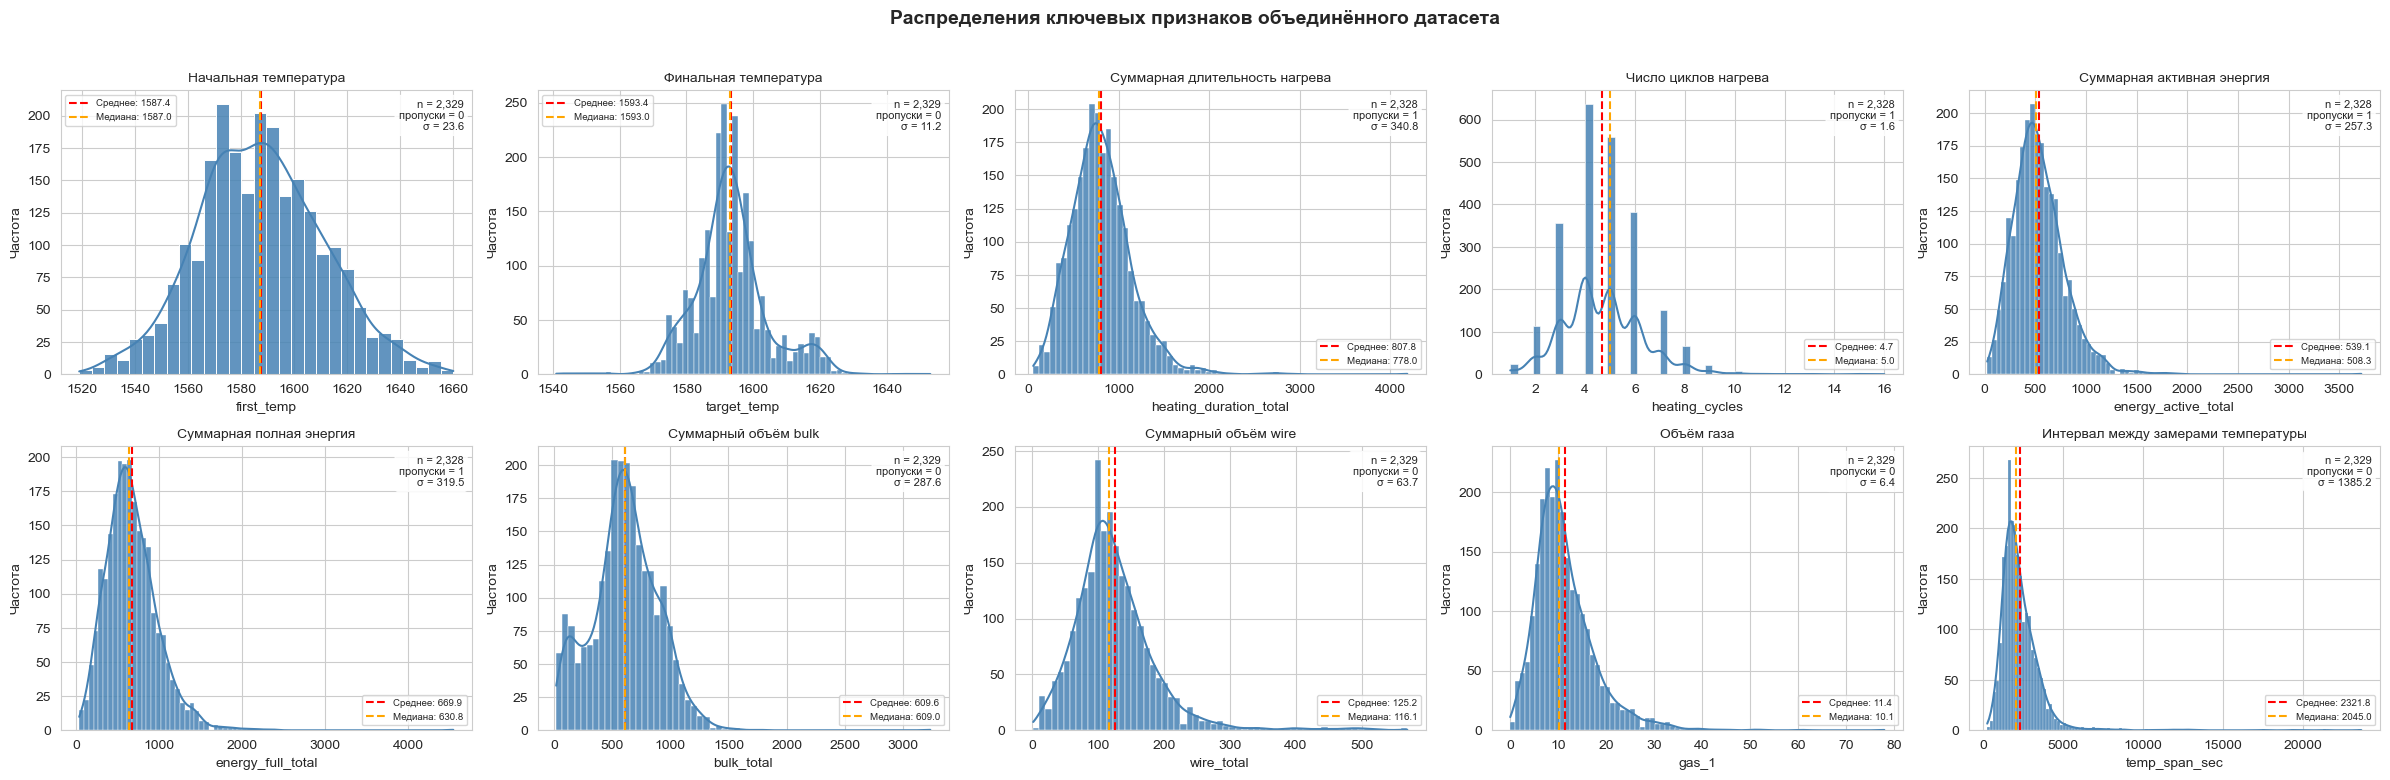

Saved: ../images/key_features_vs_target_temp.png


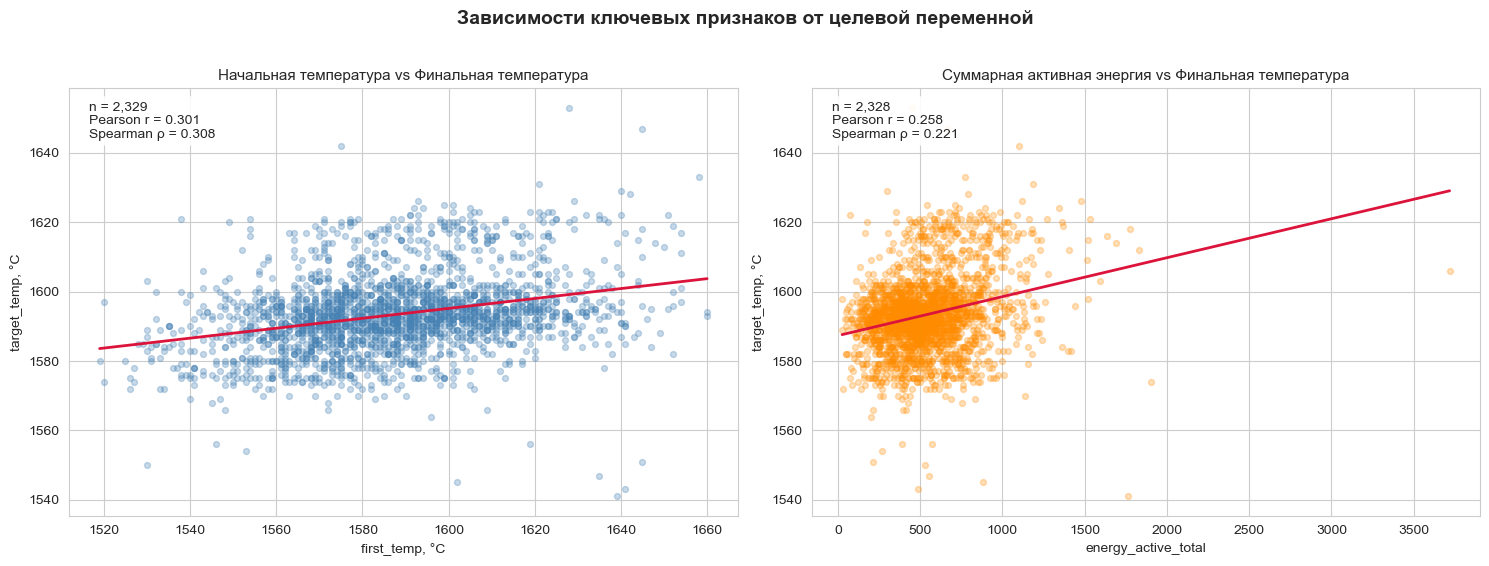

In [32]:
# ключевые признаки для визуализации EDA
key_features = [
	'first_temp', 'target_temp',
	'heating_duration_total', 'heating_cycles',
	'energy_active_total', 'energy_full_total',
	'bulk_total', 'wire_total', 'gas_1', 'temp_span_sec'
]

feature_labels = {
	'first_temp': 'Начальная температура',
	'target_temp': 'Финальная температура',
	'heating_duration_total': 'Суммарная длительность нагрева',
	'heating_cycles': 'Число циклов нагрева',
	'energy_active_total': 'Суммарная активная энергия',
	'energy_full_total': 'Суммарная полная энергия',
	'bulk_total': 'Суммарный объём bulk',
	'wire_total': 'Суммарный объём wire',
	'gas_1': 'Объём газа',
	'temp_span_sec': 'Интервал между замерами температуры'
}

available_features = [col for col in key_features if col in df.columns]
missing_features = [col for col in key_features if col not in df.columns]

if missing_features:
	print('Следующие признаки отсутствуют в df и будут пропущены:', missing_features)

sns.set_style('whitegrid')

# ----------------------------
# 1. Распределения признаков
# ----------------------------
n_cols = 5
n_rows = (len(available_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 3.8 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, available_features):
	data = df[col].dropna()

	sns.histplot(
		data,
		bins='fd',
		kde=True,
		ax=ax,
		color='steelblue',
		edgecolor='white',
		alpha=0.85
	)

	mean_val = data.mean()
	median_val = data.median()

	ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5,
			   label=f'Среднее: {mean_val:.1f}')
	ax.axvline(median_val, color='orange', linestyle='--', linewidth=1.5,
			   label=f'Медиана: {median_val:.1f}')

	ax.set_title(feature_labels.get(col, col), fontsize=10)
	ax.set_xlabel(col)
	ax.set_ylabel('Частота')

	stats_text = (
		f'n = {len(data):,}\n'
		f'пропуски = {df[col].isna().sum():,}\n'
		f'σ = {data.std():.1f}'
	)
	ax.text(
		0.98, 0.97, stats_text,
		transform=ax.transAxes,
		ha='right', va='top',
		fontsize=8,
		bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85)
	)
	ax.legend(fontsize=7, loc='best', frameon=True)

# скрываем лишние оси, если они есть
for ax in axes[len(available_features):]:
	ax.set_visible(False)

fig.suptitle(
	'Распределения ключевых признаков объединённого датасета',
	fontsize=14,
	fontweight='bold',
	y=1.02
)
plt.tight_layout()
save_plot('key_features_distributions')
plt.show()

# ----------------------------
# 2. Зависимости с target_temp
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# first_temp vs target_temp
plot_data_1 = df[['first_temp', 'target_temp']].dropna().copy()
corr_pearson_1 = plot_data_1[['first_temp', 'target_temp']].corr().iloc[0, 1]
corr_spearman_1 = plot_data_1[['first_temp', 'target_temp']].corr(method='spearman').iloc[0, 1]

sns.regplot(
	data=plot_data_1,
	x='first_temp',
	y='target_temp',
	ax=axes[0],
	ci=None,
	scatter_kws={'alpha': 0.3, 's': 18, 'color': 'steelblue'},
	line_kws={'color': 'crimson', 'linewidth': 2}
)

axes[0].set_xlabel('first_temp, °C')
axes[0].set_ylabel('target_temp, °C')
axes[0].set_title('Начальная температура vs Финальная температура', fontsize=11)
axes[0].text(
	0.03, 0.97,
	f'n = {len(plot_data_1):,}\nPearson r = {corr_pearson_1:.3f}\nSpearman ρ = {corr_spearman_1:.3f}',
	transform=axes[0].transAxes,
	ha='left', va='top',
	fontsize=10,
	bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9)
)

# energy_active_total vs target_temp
plot_data_2 = df[['energy_active_total', 'target_temp']].dropna().copy()
corr_pearson_2 = plot_data_2[['energy_active_total', 'target_temp']].corr().iloc[0, 1]
corr_spearman_2 = plot_data_2[['energy_active_total', 'target_temp']].corr(method='spearman').iloc[0, 1]

sns.regplot(
	data=plot_data_2,
	x='energy_active_total',
	y='target_temp',
	ax=axes[1],
	ci=None,
	scatter_kws={'alpha': 0.28, 's': 18, 'color': 'darkorange'},
	line_kws={'color': 'crimson', 'linewidth': 2}
)

axes[1].set_xlabel('energy_active_total')
axes[1].set_ylabel('target_temp, °C')
axes[1].set_title('Суммарная активная энергия vs Финальная температура', fontsize=11)
axes[1].text(
	0.03, 0.97,
	f'n = {len(plot_data_2):,}\nPearson r = {corr_pearson_2:.3f}\nSpearman ρ = {corr_spearman_2:.3f}',
	transform=axes[1].transAxes,
	ha='left', va='top',
	fontsize=10,
	bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9)
)

fig.suptitle(
	'Зависимости ключевых признаков от целевой переменной',
	fontsize=14,
	fontweight='bold',
	y=1.02
)
plt.tight_layout()
save_plot('key_features_vs_target_temp')
plt.show()

Saved: ../images/key_features_boxplots.png


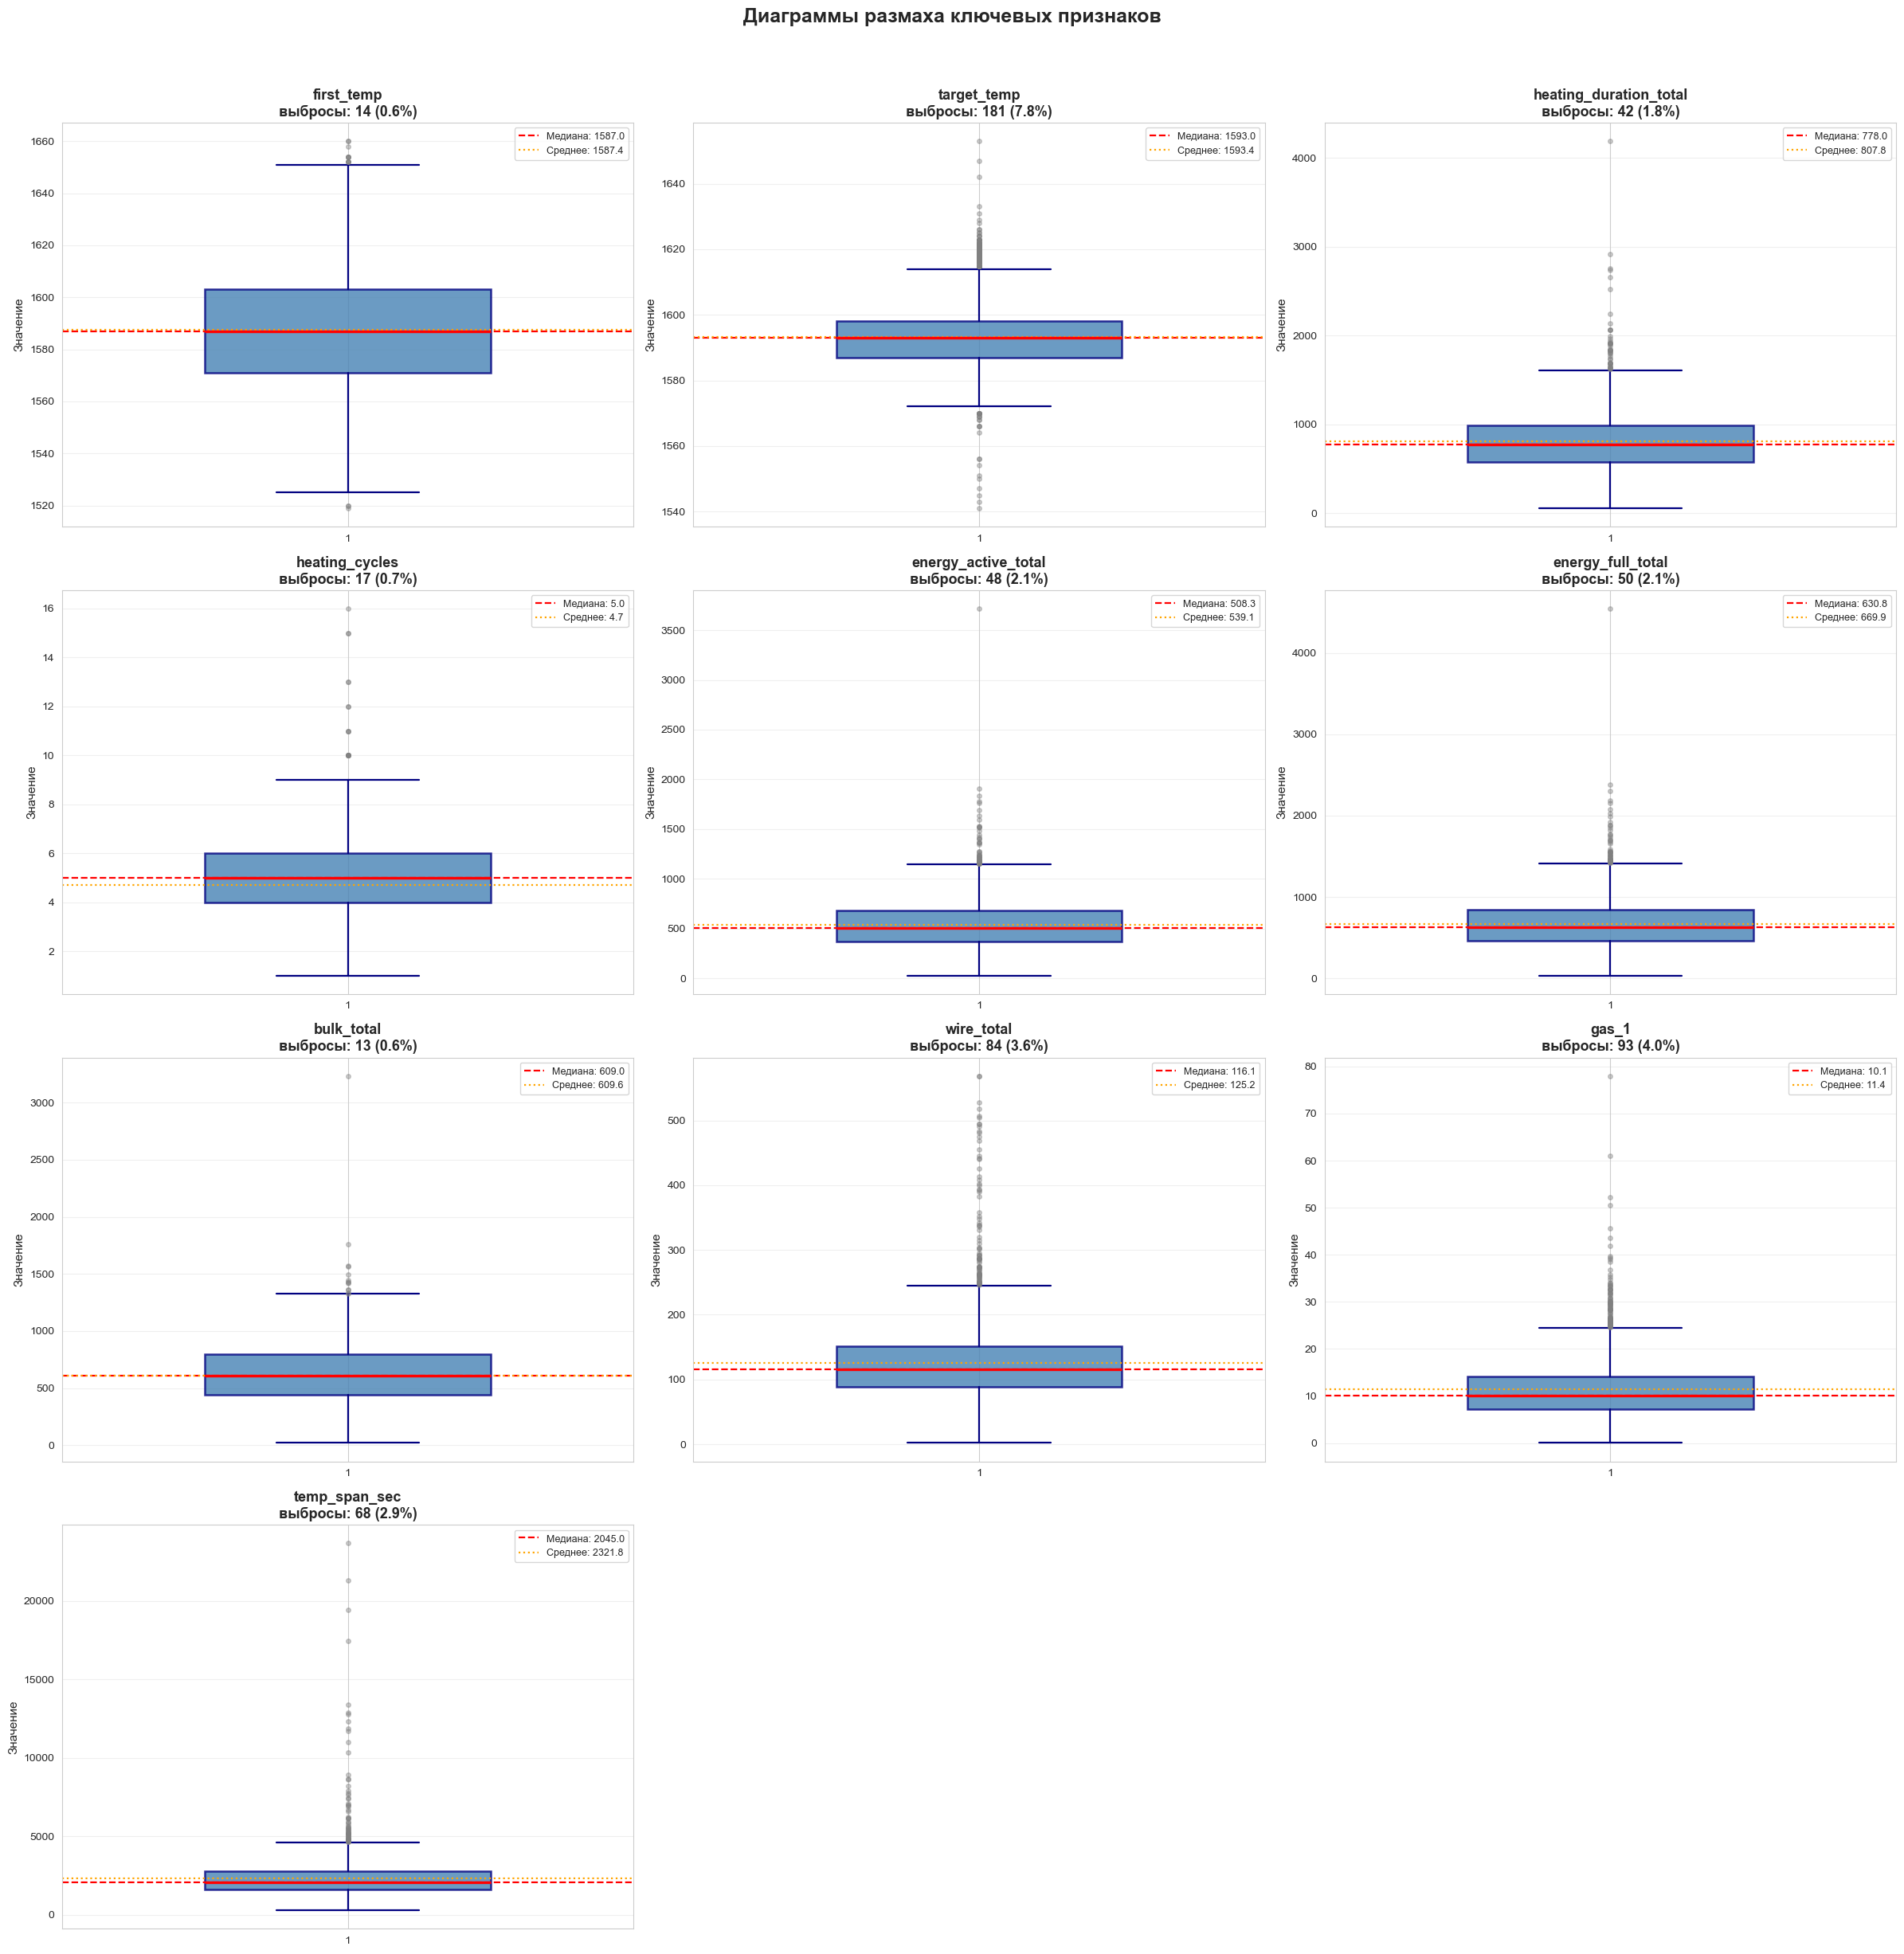


Сводка по потенциальным выбросам (метод IQR):


,phik_corr,медиана,среднее,Q1,Q3,IQR,нижняя граница,верхняя граница,выбросов,% выбросов,min,max,асимметрия
признак,,,,,,,,,,,,,
target_temp,nan,1593.00,1593.37,1587.00,1598.00,11.00,1570.50,1614.50,181,7.77,1541.00,1653.00,0.45
gas_1,nan,10.10,11.38,7.28,14.22,6.93,-3.12,24.62,93,3.99,0.01,78.00,2.00
wire_total,nan,116.10,125.21,89.01,151.57,62.55,-4.82,245.40,84,3.61,1.92,568.78,2.08
temp_span_sec,nan,2045.00,2321.81,1579.00,2791.00,1212.00,-239.00,4609.00,68,2.92,270.00,23674.00,5.83
energy_full_total,nan,630.81,669.91,457.87,841.46,383.59,-117.51,1416.84,50,2.15,33.43,4546.41,1.59
energy_active_total,nan,508.26,539.11,368.19,678.51,310.32,-97.29,1143.99,48,2.06,26.19,3718.05,1.64
heating_duration_total,nan,778.00,807.81,581.00,993.00,412.00,-37.00,1611.00,42,1.80,57.00,4189.00,1.27
heating_cycles,nan,5.00,4.70,4.00,6.00,2.00,1.00,9.00,17,0.73,1.00,16.00,0.90
first_temp,nan,1587.00,1587.39,1571.00,1603.00,32.00,1523.00,1651.00,14,0.60,1519.00,1660.00,0.14


Exception ignored in: <function ResourceTracker.__del__ at 0x110991bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x111655bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1111a5bc0>
Traceback (most recent call last

In [33]:
# диаграммы размаха и сводка по выбросам (IQR) — крупнее и читабельнее

# гарантируем, что phik_target существует даже при раннем запуске этой ячейки


phik_target = pd.Series(dtype=float, name='target_temp')  # заглушка на случай раннего запуска

if 'phik_target' not in globals() or not isinstance(phik_target, pd.Series):
    phik_target = pd.Series(dtype=float, name='target_temp')


# если phik_target уже рассчитан, упорядочим признаки по силе связи с target_temp
if not phik_target.empty:
	plot_features = (
		pd.Series(index=key_features, data=[phik_target.get(col, np.nan) for col in key_features])
		.sort_values(ascending=False, na_position='last')
		.index
		.tolist()
	)
else:
	plot_features = key_features.copy()

# меньше графиков в строке => каждый график крупнее
n_cols = 3
n_rows = int(np.ceil(len(plot_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 6 * n_rows))
axes = np.array(axes).reshape(-1)

outlier_summary = []

for ax, col in zip(axes, plot_features):
	data = df[col].dropna()

	if data.empty:
		ax.set_visible(False)
		continue

	q1 = data.quantile(0.25)
	q3 = data.quantile(0.75)
	iqr = q3 - q1
	lo = q1 - 1.5 * iqr
	hi = q3 + 1.5 * iqr
	out_mask = (data < lo) | (data > hi)
	n_out = int(out_mask.sum())
	pct_out = n_out / len(data) * 100
	median_val = data.median()
	mean_val = data.mean()
	phik_val = phik_target.get(col, np.nan) if 'phik_target' in globals() else np.nan

	ax.boxplot(
		data,
		vert=True,
		patch_artist=True,
		widths=0.5,
		boxprops=dict(facecolor='steelblue', color='navy', alpha=0.8, linewidth=1.8),
		whiskerprops=dict(color='navy', linewidth=1.6),
		capprops=dict(color='navy', linewidth=1.6),
		medianprops=dict(color='red', linewidth=2.4),
		flierprops=dict(
			marker='o',
			markerfacecolor='gray',
			markeredgecolor='gray',
			alpha=0.4,
			markersize=4
		)
	)

	ax.axhline(median_val, color='red', linestyle='--', linewidth=1.6, label=f'Медиана: {median_val:.1f}')
	ax.axhline(mean_val, color='orange', linestyle=':', linewidth=1.6, label=f'Среднее: {mean_val:.1f}')

	title = f'{col}\nвыбросы: {n_out} ({pct_out:.1f}%)'
	if not np.isnan(phik_val):
		title += f' | phik: {phik_val:.3f}'

	ax.set_title(title, fontsize=13, fontweight='bold')
	ax.set_ylabel('Значение', fontsize=11)
	ax.tick_params(axis='both', labelsize=10)
	ax.grid(axis='y', alpha=0.3)
	ax.legend(fontsize=9, loc='best')

	outlier_summary.append({
		'признак': col,
		'phik_corr': round(phik_val, 4) if not np.isnan(phik_val) else np.nan,
		'медиана': round(median_val, 2),
		'среднее': round(mean_val, 2),
		'Q1': round(q1, 2),
		'Q3': round(q3, 2),
		'IQR': round(iqr, 2),
		'нижняя граница': round(lo, 2),
		'верхняя граница': round(hi, 2),
		'выбросов': n_out,
		'% выбросов': round(pct_out, 2),
		'min': round(data.min(), 2),
		'max': round(data.max(), 2),
		'асимметрия': round(data.skew(), 3)
	})

# скрываем лишние оси
for ax in axes[len(plot_features):]:
	ax.set_visible(False)

plt.suptitle('Диаграммы размаха ключевых признаков', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('key_features_boxplots')
plt.show()

# сводная таблица выбросов
print('\nСводка по потенциальным выбросам (метод IQR):')
outlier_summary_df = (
	pd.DataFrame(outlier_summary)
	.sort_values(['% выбросов', 'phik_corr'], ascending=[False, False])
	.set_index('признак')
)

display(outlier_summary_df.style.format(precision=2))

Исследовательский анализ объединённого датасета показал следующее.

**Целевой признак `target_temp`** распределён достаточно компактно, с небольшой правосторонней асимметрией. Основная часть значений сосредоточена в относительно узком диапазоне, что соответствует логике технологического процесса и делает задачу регрессии вполне рабочей.

**Начальная температура `first_temp`** ожидаемо связана с целевой переменной: чем выше исходная температура партии, тем выше, как правило, и финальная температура сплава.

**Признаки материалов** (`bulk_total`, `wire_total`) имеют выраженную правостороннюю асимметрию. Для большинства партий объёмы добавок сравнительно умеренные, однако встречаются и партии с заметно большими значениями. Для производственных данных такая картина выглядит естественно.

**Признаки нагрева** (`heating_duration_total`, `energy_active_total`, `energy_full_total`) также скошены вправо. Это означает, что часть партий требует более длительной и интенсивной обработки электродами по сравнению с основной массой наблюдений.

Выбросы присутствуют в нескольких признаках, однако их доля в большинстве случаев невелика. С учётом предметной области такие значения, скорее всего, отражают реальные различия в режиме обработки партий, а не ошибки данных.

### Корреляционный анализ

Отдельно посмотрим корреляции между признаками и целевой переменной, чтобы выявить потенциально значимые факторы и проверить наличие мультиколлинеарности.

Признаков для phik-анализа: 43
Исключены константные признаки:
['Wire 5']
Saved: ../images/phik_correlation_matrix.png


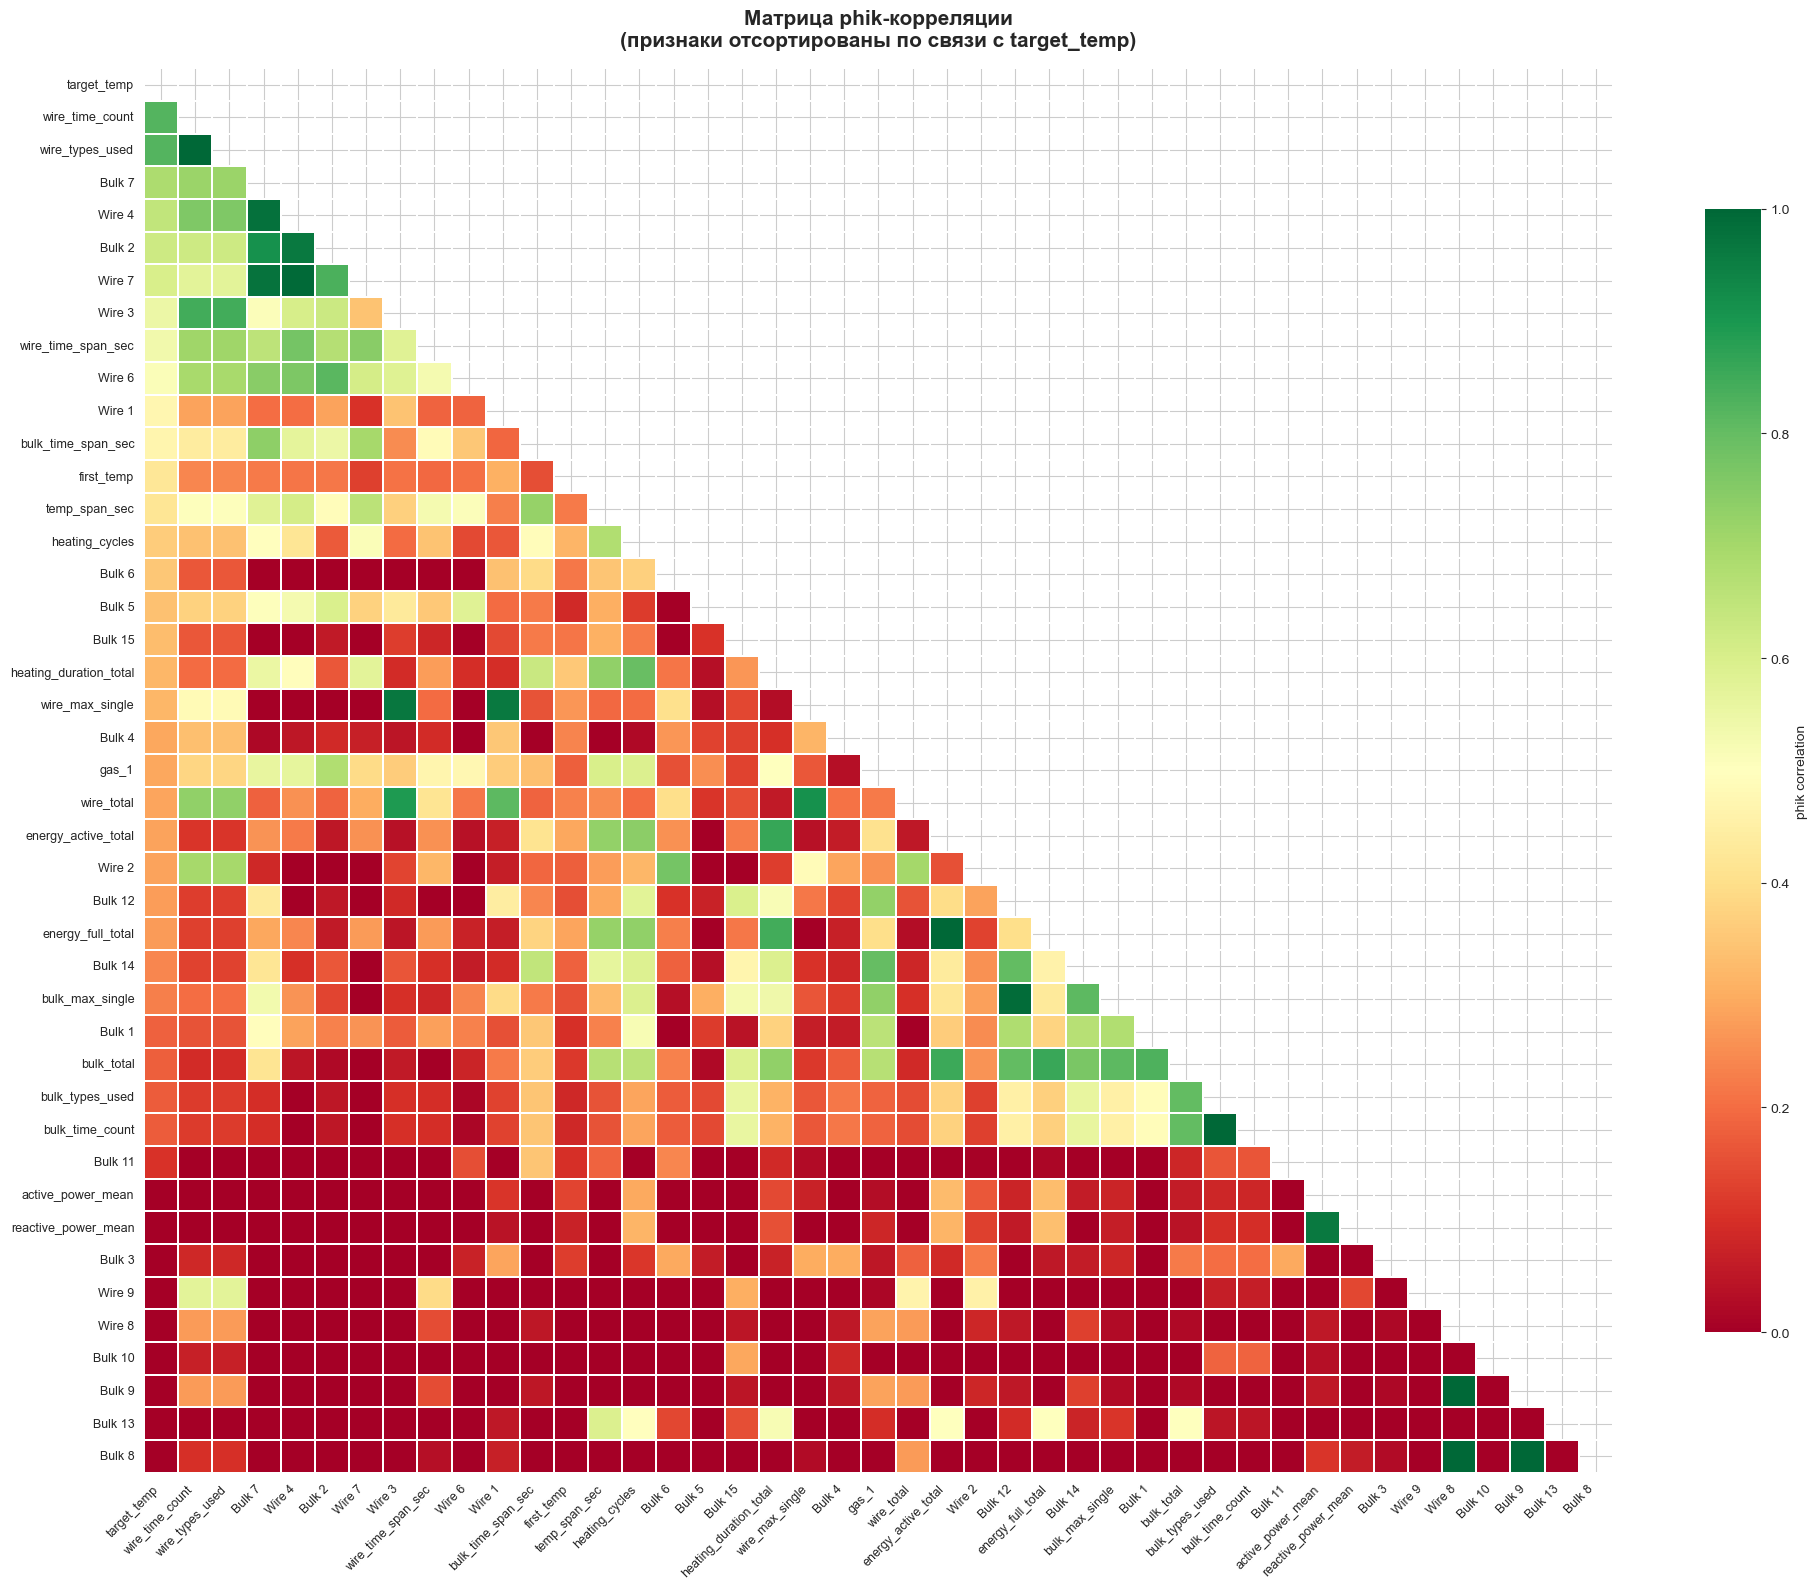

Saved: ../images/top_15_phik_correlation_matrix.png


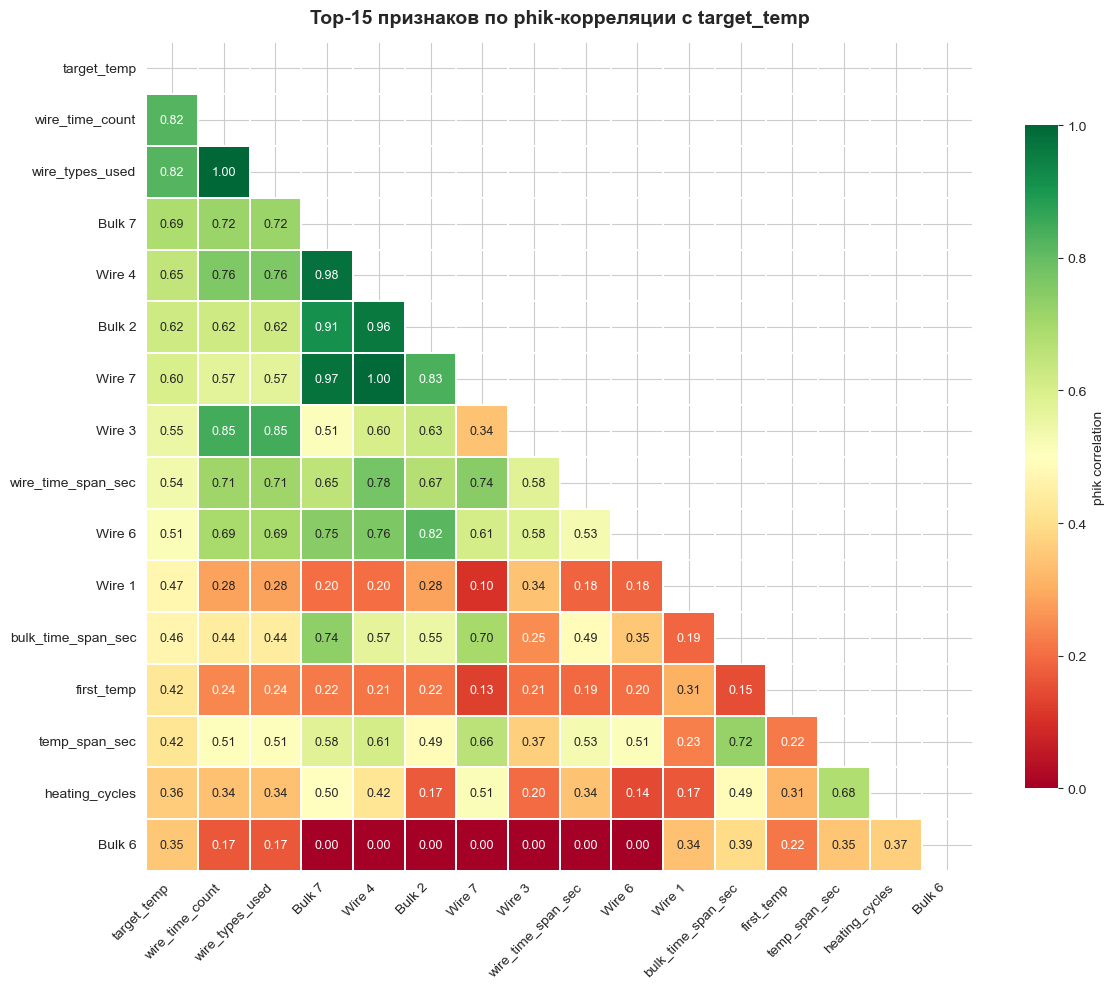


Топ-15 признаков по phik-корреляции с target_temp:


,phik_corr
wire_time_count,0.8241
wire_types_used,0.8241
Bulk 7,0.6874
Wire 4,0.6479
Bulk 2,0.6232
Wire 7,0.5997
Wire 3,0.5492
wire_time_span_sec,0.5382
Wire 6,0.5129
Wire 1,0.4705


Saved: ../images/top_15_phik_correlation_bars.png


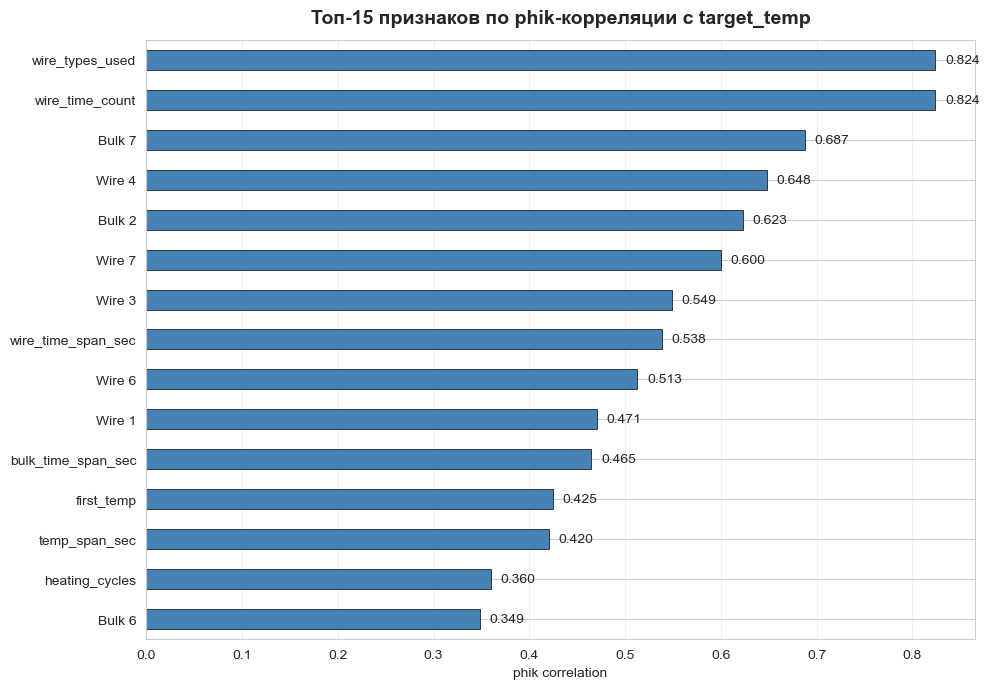


Признаки с нулевой phik-корреляцией:


,phik_corr
active_power_mean,0.0
reactive_power_mean,0.0
Bulk 3,0.0
Wire 9,0.0
Wire 8,0.0
Bulk 10,0.0
Bulk 9,0.0
Bulk 13,0.0
Bulk 8,0.0


<Figure size 640x480 with 0 Axes>

In [35]:
# phik-корреляция 
target_col = 'target_temp'
analysis_cols = [c for c in df.columns if c != 'key']

# исключаем константные признаки
nunique = df[analysis_cols].nunique(dropna=False)
constant_cols = nunique[nunique <= 1].index.tolist()
analysis_cols = [c for c in analysis_cols if c not in constant_cols]

print(f'Признаков для phik-анализа: {len(analysis_cols)}')
if constant_cols:
	print('Исключены константные признаки:')
	print(constant_cols)

# phik для числовых признаков
interval_cols = [c for c in analysis_cols if pd.api.types.is_numeric_dtype(df[c])]
phik_corr = phik_matrix(df[analysis_cols], interval_cols=interval_cols)

# корреляции с целевой переменной
phik_target = (
	phik_corr[target_col]
	.drop(target_col)
	.sort_values(ascending=False)
)

# сортируем матрицу по силе связи с target_temp
ordered_cols = [target_col] + phik_target.index.tolist()
phik_corr_ordered = phik_corr.loc[ordered_cols, ordered_cols]

# полная тепловая карта без annot — так она остается читаемой
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(phik_corr_ordered, dtype=bool))
sns.heatmap(
	phik_corr_ordered,
	mask=mask,
	cmap='RdYlGn',
	vmin=0,
	vmax=1,
	linewidths=0.3,
	cbar_kws={'label': 'phik correlation', 'shrink': 0.8}
)
plt.title(
	'Матрица phik-корреляции\n(признаки отсортированы по связи с target_temp)',
	fontsize=15,
	fontweight='bold',
	pad=16
)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
save_plot('phik_correlation_matrix')
plt.show()

# компактная матрица только для top-N признаков
top_n = 15
top_features = phik_target.head(top_n).index.tolist()
top_matrix = phik_corr.loc[[target_col] + top_features, [target_col] + top_features]

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(top_matrix, dtype=bool))
sns.heatmap(
	top_matrix,
	mask=mask,
	annot=True,
	fmt='.2f',
	cmap='RdYlGn',
	vmin=0,
	vmax=1,
	linewidths=0.3,
	annot_kws={'size': 9},
	cbar_kws={'label': 'phik correlation', 'shrink': 0.8}
)
plt.title(
	f'Top-{top_n} признаков по phik-корреляции с {target_col}',
	fontsize=14,
	fontweight='bold',
	pad=14
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
save_plot(f'top_{top_n}_phik_correlation_matrix')
plt.show()

print(f'\nТоп-{top_n} признаков по phik-корреляции с {target_col}:')
display(phik_target.head(top_n).to_frame(name='phik_corr').round(4))

top_bars = phik_target.head(top_n).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
top_bars.plot(
	kind='barh',
	ax=ax,
	color='steelblue',
	edgecolor='black',
	linewidth=0.5
)
ax.set_title(
	f'Топ-{top_n} признаков по phik-корреляции с {target_col}',
	fontsize=14,
	fontweight='bold',
	pad=12
)
ax.set_xlabel('phik correlation')
ax.set_ylabel('')
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(top_bars.values):
	ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
save_plot(f'top_{top_n}_phik_correlation_bars')
plt.show()

# признаки с нулевой phik-корреляцией
zero_phik = phik_target[phik_target == 0]
if not zero_phik.empty:
	print('\nПризнаки с нулевой phik-корреляцией:')
	display(zero_phik.to_frame(name='phik_corr'))

plt.tight_layout()
plt.show()


Анализ phik-корреляций показал, что связь признаков с целевой переменной распределена неравномерно.

Наиболее сильную связь с `target_temp` показали признаки, связанные с проволочными материалами: `wire_time_count`, `wire_types_used`, а также отдельные признаки `Wire 4`, `Wire 7`, `Wire 3`, `Wire 6` и `Wire 1`. Также заметную связь продемонстрировали некоторые признаки сыпучих материалов, в частности `Bulk 7`, `Bulk 2` и `Bulk 6`.

Из технологических признаков наиболее выраженная связь с целевой переменной наблюдается у `first_temp`, `temp_span_sec` и `heating_cycles`. Это выглядит содержательно: исходная температура партии, длительность температурного цикла и число этапов нагрева действительно могут влиять на финальную температуру сплава.

При этом часть признаков показала нулевую phik-корреляцию с целевой переменной: `active_power_mean`, `reactive_power_mean`, `Bulk 10`, `Bulk 13`, `Bulk 3`, `Bulk 9`, `Bulk 8`, `Wire 8` и `Wire 9`. Такие признаки не демонстрируют выраженной индивидуальной связи с таргетом и могут рассматриваться как кандидаты на исключение из модели.

Однако окончательное решение об исключении признаков следует принимать не только по значению phik-корреляции, но и с учётом их содержательного смысла, редкости использования и влияния на качество модели при кросс-валидации. Поэтому признаки с нулевой или очень слабой связью с целевой переменной будут исключаться только после дополнительной проверки.

Pearson-корреляция признаков с target_temp (топ-20 по модулю):


,corr,abs_corr
Wire 1,0.3176,0.3176
first_temp,0.3013,0.3013
heating_duration_total,0.2781,0.2781
Bulk 12,0.2674,0.2674
Bulk 15,0.2664,0.2664
energy_active_total,0.2580,0.2580
energy_full_total,0.2561,0.2561
wire_max_single,0.2367,0.2367
bulk_total,0.2227,0.2227
Wire 2,-0.2067,0.2067


Saved: ../images/pearson_correlation_with_target_temp.png


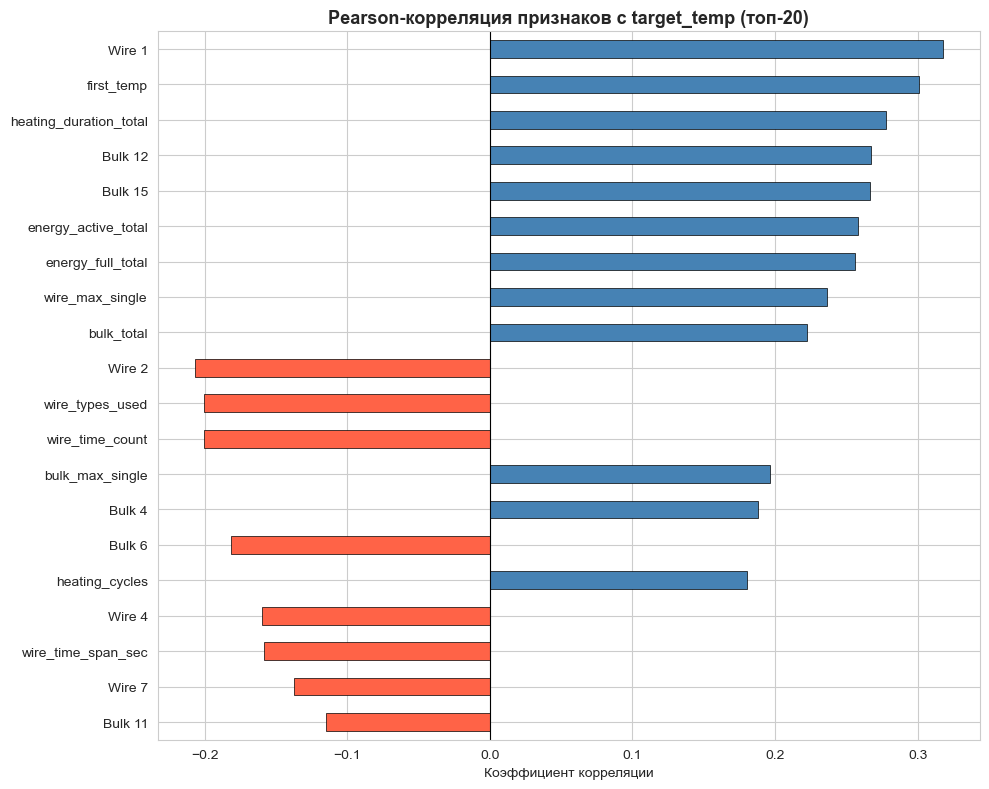


Пары признаков с мультиколлинеарностью (|corr| > 0.9):


,признак_1,признак_2,корреляция
0,bulk_types_used,bulk_time_count,1.000
1,wire_types_used,wire_time_count,1.000
2,energy_active_total,energy_full_total,0.999
3,Bulk 9,Wire 8,0.975
4,active_power_mean,reactive_power_mean,0.965
5,heating_duration_total,energy_active_total,0.902
6,heating_duration_total,energy_full_total,0.900


In [36]:
# Pearson-корреляция числовых признаков с целевой переменной
num_cols = df.select_dtypes(include='number').columns.tolist()
feature_cols_for_corr = [c for c in num_cols if c != 'target_temp']

pearson_with_target = (
    df[feature_cols_for_corr + ['target_temp']]
    .corr()['target_temp']
    .drop('target_temp')
)
pearson_sorted = pearson_with_target.abs().sort_values(ascending=False)

print('Pearson-корреляция признаков с target_temp (топ-20 по модулю):')
display(
    pearson_with_target.reindex(pearson_sorted.index)
    .head(20)
    .to_frame(name='corr')
    .assign(abs_corr=lambda x: x['corr'].abs())
    .round(4)
)

fig, ax = plt.subplots(figsize=(10, 8))
top20 = pearson_with_target.reindex(pearson_sorted.index).head(20)
colors = ['steelblue' if v >= 0 else 'tomato' for v in top20]
top20.plot(kind='barh', ax=ax, color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson-корреляция признаков с target_temp (топ-20)', fontsize=13, fontweight='bold')
ax.set_xlabel('Коэффициент корреляции')
ax.invert_yaxis()
plt.tight_layout()
save_plot('pearson_correlation_with_target_temp')
plt.show()

# мультиколлинеарность: пары признаков с корреляцией > 0.9
corr_matrix = df[feature_cols_for_corr].corr().abs()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.9:
            high_corr_pairs.append({
                'признак_1': corr_matrix.columns[i],
                'признак_2': corr_matrix.columns[j],
                'корреляция': round(corr_matrix.iloc[i, j], 3)
            })

if high_corr_pairs:
    print('\nПары признаков с мультиколлинеарностью (|corr| > 0.9):')
    display(
        pd.DataFrame(high_corr_pairs)
        .sort_values('корреляция', ascending=False)
        .reset_index(drop=True)
    )
else:
    print('\nПар признаков с выраженной мультиколлинеарностью (|corr| > 0.9) не обнаружено.')

Анализ линейных корреляций показал, что самые заметные положительные связи с `target_temp` имеют `Wire 1`, `first_temp`, `heating_duration_total`, `Bulk 12`, `Bulk 15`, `energy_active_total` и `energy_full_total`. Это выглядит содержательно: финальная температура действительно должна быть связана как с исходной температурой партии, так и с интенсивностью нагрева и объёмом части добавок.

При этом у некоторых признаков наблюдается отрицательная линейная связь с целевой переменной. Наиболее заметно это для `Wire 2`, `wire_types_used`, `wire_time_count`, `Bulk 6`, `Wire 4`, `wire_time_span_sec` и `Wire 7`. Это не означает, что признаки «плохие», а лишь показывает направление линейной зависимости в данных.

По абсолютной величине коэффициенты Pearson в основном умеренные, без экстремально высоких значений. Это говорит о том, что сильной простой линейной зависимости с таргетом у большинства признаков нет, а значит, для задачи могут быть полезны и более гибкие модели, способные учитывать нелинейные эффекты и взаимодействия признаков.

Отдельно была проверена мультиколлинеарность между признаками. Обнаружены несколько пар с очень высокой корреляцией:
- `wire_types_used` и `wire_time_count`;
- `bulk_types_used` и `bulk_time_count`;
- `energy_active_total` и `energy_full_total`;
- `active_power_mean` и `reactive_power_mean`.

Кроме того, очень тесно связаны `heating_duration_total` с `energy_active_total` и `energy_full_total`. Это ожидаемо, поскольку энергетические признаки напрямую зависят от длительности нагрева.

С практической точки зрения это означает, что в линейные модели не стоит одновременно включать все такие признаки, поскольку это может ухудшить устойчивость коэффициентов и интерпретацию модели. Поэтому на этапе подготовки итогового набора признаков часть сильно коррелирующих между собой переменных целесообразно исключить, оставив более информативные и содержательно интерпретируемые признаки.

#### Вывод

Корреляционный анализ в целом подтвердил ожидаемые закономерности.

По phik-матрице и Pearson-корреляции наиболее устойчивую связь с целевой переменной `target_temp` показывает `first_temp` — начальная температура партии. Это логично с технологической точки зрения: чем выше температура сплава в начале обработки, тем выше, как правило, и его финальная температура.

Заметную связь с целевой переменной также показывают признаки, связанные с нагревом: `energy_active_total`, `heating_duration_total` и `heating_cycles`. Эти признаки отражают интенсивность и длительность работы электродов, поэтому их влияние на итоговую температуру выглядит ожидаемым.

Для части bulk- и wire-признаков линейная связь с `target_temp` выражена слабо, однако phik-анализ показывает, что некоторые из них всё же связаны с целевой переменной. Это указывает на то, что их влияние может быть нелинейным или проявляться в комбинации с другими признаками.

Таким образом, на этапе моделирования стоит учитывать, что линейные модели лучше отражают общие и более простые зависимости, тогда как ансамблевые методы потенциально смогут лучше уловить сложные нелинейные эффекты.

## Подготовка данных к моделированию

После завершения анализа сформируем итоговый набор признаков для обучения модели.

На этом этапе отделим признаки от целевой переменной, разделим данные на обучающую и тестовую выборки и при необходимости выполним масштабирование признаков.

In [21]:
# формирование финального набора признаков
drop_cols = ['key', 'target_temp']

# bulk и wire уже заполнены нулями, поэтому fill_rate здесь неинформативен.
# вместо этого считаем долю ненулевых значений: если признак используется менее чем в 10% партий,
# он слишком разреженный и, вероятно, добавляет больше шума, чем сигнала.
non_zero_rate = (df.drop(columns=drop_cols, errors='ignore') != 0).mean()
rare_cols = non_zero_rate[non_zero_rate < 0.10].index.tolist()

if rare_cols:
    print(f'Признаки с долей ненулевых значений < 10% ({len(rare_cols)} шт.) — исключаем:')
    display(
        pd.Series(non_zero_rate[rare_cols], name='non_zero_rate')
        .sort_values()
        .to_frame()
        .style.format('{:.3f}')
    )
    drop_cols += rare_cols
else:
    print('Слишком редких признаков (< 10% ненулевых) не обнаружено.')

# признаки с нулевой phik-корреляцией с таргетом рассматриваются как слабые кандидаты;
# здесь исключаем только те, которые дополнительно слабо интерпретируются
# и не несут полезной информации по сравнению с более содержательными агрегатами
zero_phik_cols = ['active_power_mean', 'reactive_power_mean']
drop_cols += [c for c in zero_phik_cols if c not in drop_cols]
print(f'\nПризнаки с нулевой phik-корреляцией — исключаем: {zero_phik_cols}')

# удаление дублирующих признаков
# energy_full_total почти полностью дублирует energy_active_total,
# поэтому оставляем более простой и интерпретируемый признак energy_active_total
# bulk_time_count в текущих данных практически дублирует bulk_types_used,
# поэтому оставляем bulk_types_used
redundant_cols = ['energy_full_total', 'bulk_time_count']
drop_cols += [c for c in redundant_cols if c not in drop_cols]
print(f'Дублирующие признаки — исключаем: {redundant_cols}')

drop_cols = list(dict.fromkeys(drop_cols))

X = df.drop(columns=drop_cols, errors='ignore')
y = df['target_temp']

valid_mask = y.notna()
X = X[valid_mask].reset_index(drop=True)
y = y[valid_mask].reset_index(drop=True)

print(f'\nРазмер матрицы признаков X: {X.shape}')
print(f'Размер целевого вектора y: {y.shape}')
print(f'\nПризнаки модели ({X.shape[1]} шт.):')
print(X.columns.tolist())

# разбивка на обучающую и тестовую выборки: 75/25
# тестовая выборка используется только для финальной оценки лучшей модели
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

print(f'\nОбучающая выборка: {X_train.shape[0]} строк')
print(f'Тестовая выборка:  {X_test.shape[0]} строк')

Признаки с долей ненулевых значений < 10% (16 шт.) — исключаем:


,non_zero_rate
Wire 5,0.000
Bulk 8,0.000
Wire 7,0.002
Wire 4,0.005
Bulk 2,0.006
Bulk 7,0.006
Bulk 9,0.006
Wire 8,0.006
Bulk 13,0.006
Wire 9,0.010



Признаки с нулевой phik-корреляцией — исключаем: ['active_power_mean', 'reactive_power_mean']
Дублирующие признаки — исключаем: ['energy_full_total', 'bulk_time_count']

Размер матрицы признаков X: (2329, 23)
Размер целевого вектора y: (2329,)

Признаки модели (23 шт.):
['first_temp', 'temp_span_sec', 'heating_duration_total', 'heating_cycles', 'energy_active_total', 'Bulk 12', 'Bulk 14', 'Bulk 15', 'Bulk 3', 'Bulk 4', 'Bulk 6', 'bulk_total', 'bulk_types_used', 'bulk_max_single', 'bulk_time_span_sec', 'Wire 1', 'Wire 2', 'wire_total', 'wire_types_used', 'wire_max_single', 'wire_time_span_sec', 'wire_time_count', 'gas_1']

Обучающая выборка: 1746 строк
Тестовая выборка:  583 строк


Данные подготовлены к обучению моделей.

Из итогового набора признаков были исключены идентификатор партии `key`, целевая переменная `target_temp`, слишком разреженные признаки с долей ненулевых значений менее 10%, а также часть слабых и дублирующих друг друга признаков.

После этого был сформирован итоговый набор признаков для моделирования. Данные разделены на обучающую и тестовую выборки в соотношении 75:25. **Тестовая выборка зарезервирована и будет использована только один раз — для финальной оценки лучшей модели.**

`temp_span_sec` — время между первым и последним замером температуры партии — формально утечкой не является: в признак попадает только временной интервал, но не само значение финальной температуры. При этом длительность измерений отражает реальную характеристику процесса обработки, поэтому признак был оставлен.

Заполнение пропусков и масштабирование вынесены внутрь `Pipeline`. Благодаря этому весь препроцессинг на кросс-валидации выполняется отдельно внутри каждого фолда, что позволяет избежать утечки данных.

In [22]:
df

,key,first_temp,target_temp,temp_span_sec,heating_duration_total,heating_cycles,active_power_mean,reactive_power_mean,energy_active_total,energy_full_total,Bulk 1,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,bulk_total,bulk_types_used,bulk_max_single,bulk_time_span_sec,bulk_time_count,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9,wire_total,wire_types_used,wire_max_single,wire_time_span_sec,wire_time_count,gas_1
0,1,1571.0,1613.0,1714.0,1098.0,5.0,0.607346,0.428564,628.616930,770.282114,0.0,0.0,0.0,206.0,0.0,150.0,154.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,553.0,4,206.0,1085.0,4,60.059998,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.059998,1,60.059998,0.0,1,29.749986
1,2,1581.0,1602.0,1265.0,811.0,4.0,0.534852,0.363339,395.281800,481.760005,0.0,0.0,0.0,206.0,0.0,149.0,154.0,0.0,0.0,73.0,0.0,0.0,0.0,0.0,0.0,582.0,4,206.0,1000.0,4,96.052315,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,96.052315,1,96.052315,0.0,1,12.555561
2,3,1596.0,1599.0,1753.0,655.0,5.0,0.812728,0.587491,581.774624,722.837668,0.0,0.0,0.0,205.0,0.0,152.0,153.0,0.0,0.0,34.0,0.0,0.0,0.0,0.0,0.0,544.0,4,205.0,983.0,4,91.160157,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,91.160157,1,91.160157,0.0,1,28.554793
3,4,1601.0,1625.0,1220.0,741.0,4.0,0.676622,0.514248,543.710274,683.455597,0.0,0.0,0.0,207.0,0.0,153.0,154.0,0.0,0.0,81.0,0.0,0.0,0.0,0.0,0.0,595.0,4,207.0,878.0,4,89.063515,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,89.063515,1,89.063515,0.0,1,18.841219
4,5,1576.0,1602.0,1536.0,869.0,4.0,0.563238,0.421998,412.180480,512.169934,0.0,0.0,0.0,203.0,0.0,151.0,152.0,0.0,0.0,78.0,0.0,0.0,0.0,0.0,0.0,584.0,4,203.0,205.0,4,89.238236,9.11456,0.0,0.0,0.0,0.0,0.0,0.0,0.0,98.352796,2,89.238236,310.0,2,5.413692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2324,2495,1570.0,1591.0,1380.0,723.0,4.0,0.792033,0.552734,571.539318,694.177326,0.0,90.0,0.0,256.0,0.0,129.0,223.0,0.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0,719.0,5,256.0,1002.0,5,89.150879,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,89.150879,1,89.150879,0.0,1,7.125735
2325,2496,1554.0,1591.0,1705.0,940.0,6.0,0.695820,0.478672,675.222467,815.818538,0.0,122.0,0.0,256.0,0.0,129.0,226.0,0.0,0.0,63.0,0.0,0.0,0.0,0.0,0.0,796.0,5,256.0,1171.0,5,114.179527,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,114.179527,1,114.179527,0.0,1,9.412616
2326,2497,1571.0,1589.0,962.0,569.0,3.0,1.201746,0.817364,680.326674,823.020520,0.0,0.0,0.0,230.0,0.0,124.0,226.0,0.0,0.0,85.0,0.0,0.0,0.0,0.0,0.0,665.0,4,230.0,668.0,4,94.086723,9.04800,0.0,0.0,0.0,0.0,0.0,0.0,0.0,103.134723,2,94.086723,340.0,2,6.271699
2327,2498,1591.0,1594.0,1520.0,750.0,5.0,0.640462,0.447964,474.918795,581.810739,0.0,101.0,0.0,206.0,0.0,129.0,207.0,0.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,733.0,5,207.0,820.0,5,118.110717,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.110717,1,118.110717,0.0,1,14.953657


In [23]:
X_train

,first_temp,temp_span_sec,heating_duration_total,heating_cycles,energy_active_total,Bulk 12,Bulk 14,Bulk 15,Bulk 3,Bulk 4,Bulk 6,bulk_total,bulk_types_used,bulk_max_single,bulk_time_span_sec,Wire 1,Wire 2,wire_total,wire_types_used,wire_max_single,wire_time_span_sec,wire_time_count,gas_1
78,1598.0,3089.0,1077.0,6.0,534.252615,105.0,256.0,0.0,0.0,0.0,109.0,470.0,3,256.0,788.0,75.260643,23.150400,98.411043,2,75.260643,835.0,2,14.381483
976,1589.0,2550.0,1227.0,7.0,910.230434,461.0,206.0,203.0,0.0,0.0,0.0,975.0,4,461.0,793.0,145.033187,0.000000,145.033187,1,145.033187,0.0,1,10.778868
982,1588.0,2633.0,931.0,5.0,553.561997,478.0,235.0,193.0,87.0,0.0,0.0,1020.0,5,478.0,1605.0,124.066803,0.000000,124.066803,1,124.066803,0.0,1,12.680359
1696,1608.0,2581.0,839.0,5.0,436.419122,479.0,203.0,0.0,0.0,136.0,0.0,899.0,5,479.0,1404.0,134.175613,0.000000,134.175613,1,134.175613,0.0,1,6.996337
1513,1594.0,1813.0,564.0,4.0,455.072143,206.0,101.0,0.0,69.0,0.0,0.0,407.0,4,206.0,651.0,120.135605,75.098396,195.234001,2,120.135605,722.0,2,1.944427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
616,1567.0,1842.0,698.0,3.0,380.318322,206.0,204.0,154.0,272.0,0.0,0.0,836.0,4,272.0,1281.0,95.518799,0.000000,95.518799,1,95.518799,0.0,1,7.083258
1274,1541.0,1575.0,876.0,4.0,591.495569,413.0,255.0,209.0,0.0,0.0,0.0,877.0,3,413.0,562.0,52.135201,0.000000,52.135201,1,52.135201,0.0,1,8.698114
764,1561.0,1443.0,642.0,3.0,502.662070,0.0,251.0,0.0,0.0,0.0,0.0,251.0,1,251.0,0.0,52.275597,0.000000,52.275597,1,52.275597,0.0,1,8.452927
105,1561.0,1614.0,874.0,5.0,568.002306,105.0,260.0,0.0,0.0,47.0,0.0,412.0,3,260.0,582.0,175.156799,0.000000,469.320411,3,254.077850,750.0,3,16.763225


## Обучение моделей

Для решения задачи обучим несколько моделей регрессии и сравним их качество.

Сравнение нескольких алгоритмов позволяет выбрать наиболее подходящую модель для прогнозирования финальной температуры сплава.

In [24]:
# вспомогательные функции для Pipeline
def make_scaled_pipeline(model):
	return Pipeline([
		('imputer', SimpleImputer(strategy='median')),
		('scaler', StandardScaler()),
		('model', model)
	])

def make_plain_pipeline(model):
	return Pipeline([
		('imputer', SimpleImputer(strategy='median')),
		('model', model)
	])

baseline_models = {
	'DummyRegressor (mean)': make_plain_pipeline(DummyRegressor(strategy='mean')),
	'LinearRegression':      make_scaled_pipeline(LinearRegression()),
	'Ridge':                 make_scaled_pipeline(Ridge()),
	'RandomForestRegressor': make_plain_pipeline(
		RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
	),
	'LGBMRegressor':         make_plain_pipeline(
		LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
	),
}

baseline_results = {}
quality_threshold = 6.8

print('Обучение базовых моделей (5-fold кросс-валидация на X_train)...\n')

for name, pipeline in baseline_models.items():
	cv_scores = cross_val_score(
		pipeline,
		X_train,
		y_train,
		cv=5,
		scoring='neg_mean_absolute_error',
		n_jobs=-1
	)

	mae_scores = -cv_scores
	mae_cv = mae_scores.mean()
	mae_std = mae_scores.std()

	pipeline.fit(X_train, y_train)
	mae_train = mean_absolute_error(y_train, pipeline.predict(X_train))

	baseline_results[name] = {
		'MAE CV (mean)': round(mae_cv, 4),
		'MAE CV (std)':  round(mae_std, 4),
		'MAE train':     round(mae_train, 4),
		'model':         pipeline
	}

	status = 'OK' if mae_cv <= quality_threshold else 'FAIL'
	print(f'{name:30s}  MAE CV = {mae_cv:.4f} ± {mae_std:.4f}  |  MAE train = {mae_train:.4f}  |  {status}')

results_df = (
	pd.DataFrame({
		k: {kk: vv for kk, vv in v.items() if kk != 'model'}
		for k, v in baseline_results.items()
	})
	.T
	.sort_values('MAE CV (mean)')
)

results_df['Критерий MAE ≤ 6.8 (CV)'] = results_df['MAE CV (mean)'] <= quality_threshold
results_df['Запас до порога'] = (quality_threshold - results_df['MAE CV (mean)']).round(4)

print(f'\nСводная таблица базовых моделей (критерий: MAE ≤ {quality_threshold}):')
display(results_df)

passed_models = results_df[results_df['Критерий MAE ≤ 6.8 (CV)']]
print(f'Моделей, прошедших критерий: {len(passed_models)} из {len(results_df)}')
if len(passed_models) > 0:
	print('Прошли критерий:', ', '.join(passed_models.index.tolist()))

Обучение базовых моделей (5-fold кросс-валидация на X_train)...

DummyRegressor (mean)           MAE CV = 8.1721 ± 0.2847  |  MAE train = 8.1645  |  FAIL
LinearRegression                MAE CV = 6.0196 ± 0.2621  |  MAE train = 5.9117  |  OK
Ridge                           MAE CV = 6.0179 ± 0.2623  |  MAE train = 5.9107  |  OK
RandomForestRegressor           MAE CV = 6.3124 ± 0.2636  |  MAE train = 2.3318  |  OK


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LGBMRegressor                   MAE CV = 6.2806 ± 0.2289  |  MAE train = 2.5421  |  OK

Сводная таблица базовых моделей (критерий: MAE ≤ 6.8):


,MAE CV (mean),MAE CV (std),MAE train,Критерий MAE ≤ 6.8 (CV),Запас до порога
Ridge,6.0179,0.2623,5.9107,True,0.7821
LinearRegression,6.0196,0.2621,5.9117,True,0.7804
LGBMRegressor,6.2806,0.2289,2.5421,True,0.5194
RandomForestRegressor,6.3124,0.2636,2.3318,True,0.4876
DummyRegressor (mean),8.1721,0.2847,8.1645,False,-1.3721


Моделей, прошедших критерий: 4 из 5
Прошли критерий: Ridge, LinearRegression, LGBMRegressor, RandomForestRegressor


Проведено предварительное сравнение базовых моделей по метрике MAE с использованием 5-кратной кросс-валидации на обучающей выборке.

В качестве ориентировочного порога на этом этапе используется значение **MAE ≤ 6.8**. Поскольку тестовая выборка зарезервирована для финальной проверки, решение о том, какие модели имеет смысл рассматривать дальше, принимается по результатам кросс-валидации на `X_train`.

Каждая модель обучалась внутри `Pipeline`: для линейных моделей использовались заполнение пропусков и масштабирование признаков, для деревьев и бустинга — только заполнение пропусков. Такой подход позволяет корректно выполнять валидацию без утечки данных, поскольку весь препроцессинг переобучается отдельно внутри каждого фолда.

По результатам сравнения четыре модели из пяти показали на кросс-валидации значение MAE ниже 6.8: `Ridge`, `LinearRegression`, `RandomForestRegressor` и `LGBMRegressor`. Базовая модель `DummyRegressor (mean)` ожидаемо не справилась с задачей и служит нижней границей качества.

Лучший результат на кросс-валидации показала модель `Ridge` (`MAE CV = 6.0179`), практически на том же уровне находится `LinearRegression`. Ансамблевые модели `RandomForestRegressor` и `LGBMRegressor` также проходят предварительный порог, однако их ошибка на обучающей выборке заметно ниже, чем на кросс-валидации. Это указывает на более выраженное переобучение по сравнению с линейными моделями.

Таким образом, на текущем этапе наиболее устойчивой выглядит модель `Ridge`. При этом важно учитывать, что порог **MAE ≤ 6.8** пока проверен только на кросс-валидации. Окончательный вывод о выполнении требования задачи можно будет сделать только после финальной оценки лучшей модели на тестовой выборке.

### Подбор гиперпараметров

Для как минимум одной модели выполняю подбор гиперпараметров, чтобы улучшить качество предсказания по сравнению с базовой конфигурацией.

In [25]:
# Тюнинг гиперпараметров:
# делаем RandomizedSearchCV на подвыборке train,
# затем дообучаем лучший пайплайн на полном X_train / y_train.

tuning_results = {}
criterion_key = f'Критерий MAE ≤ {quality_threshold} (CV)'
TUNING_FRACTION = 0.4  # доля train для подбора (ускорение)


def _subset_xy(X, y, frac=0.4, random_state=RANDOM_STATE):
	n = len(y)
	n_sub = max(1000, int(n * frac)) if n >= 1000 else max(1, int(n * frac))
	n_sub = min(n_sub, n)

	rng = np.random.RandomState(random_state)
	idx = rng.choice(n, size=n_sub, replace=False)

	if hasattr(X, 'iloc'):
		X_sub = X.iloc[idx]
	else:
		X_sub = X[idx]

	if hasattr(y, 'iloc'):
		y_sub = y.iloc[idx]
	else:
		y_sub = y[idx]

	return X_sub, y_sub

X_tune, y_tune = _subset_xy(X_train, y_train, frac=TUNING_FRACTION, random_state=RANDOM_STATE)
print(f'Тюнинг на подвыборке: {len(y_tune)} из {len(y_train)} объектов')

def run_search(model_name, estimator, param_dist, cv=3, n_iter=30):
	search = RandomizedSearchCV(
		estimator=estimator,
		param_distributions=param_dist,
		n_iter=n_iter,
		scoring='neg_mean_absolute_error',
		cv=cv,
		n_jobs=-1,
		random_state=RANDOM_STATE,
		verbose=0
	)

	search.fit(X_tune, y_tune)
	mae_cv = -search.best_score_

	# дообучаем лучший пайплайн на полном train
	best_estimator_full = search.best_estimator_
	best_estimator_full.fit(X_train, y_train)

	tuning_results[model_name] = {
		'best_params': search.best_params_,
		'MAE CV': round(mae_cv, 4),
		criterion_key: mae_cv <= quality_threshold,
		'Запас до порога': round(quality_threshold - mae_cv, 4),
		'best_estimator': best_estimator_full
	}

	print(f'  Лучшие параметры: {search.best_params_}')
	print(f'  MAE CV (subset): {mae_cv:.4f}')
	print(f'  MAE ≤ {quality_threshold}: {mae_cv <= quality_threshold}\n')

# --- RandomForestRegressor ---
print('Подбор гиперпараметров: RandomForestRegressor...')
rf_param_dist = {
	'model__n_estimators': randint(150, 450),
	'model__max_depth': [None, 8, 12, 16, 24],
	'model__min_samples_split': randint(2, 12),
	'model__min_samples_leaf': randint(1, 6),
	'model__max_features': ['sqrt', 'log2', 0.5, 0.7],
}
run_search(
	model_name='RandomForestRegressor',
	estimator=make_plain_pipeline(
		RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
	),
	param_dist=rf_param_dist,
	cv=3,
	n_iter=30
)

# --- LGBMRegressor ---
print('Подбор гиперпараметров: LGBMRegressor...')
lgbm_param_dist = {
	'model__n_estimators': randint(150, 500),
	'model__max_depth': randint(3, 10),
	'model__learning_rate': uniform(0.02, 0.18),
	'model__num_leaves': randint(24, 96),
	'model__subsample': uniform(0.6, 0.4),
	'model__colsample_bytree': uniform(0.6, 0.4),
	'model__min_child_samples': randint(8, 45),
	'model__reg_alpha': uniform(0.0, 0.3),
	'model__reg_lambda': uniform(0.0, 0.3),
}
run_search(
	model_name='LGBMRegressor',
	estimator=make_plain_pipeline(
		LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
	),
	param_dist=lgbm_param_dist,
	cv=3,
	n_iter=30
)

print('Результаты подбора гиперпараметров (выбор по CV на подвыборке train):')
tuning_summary = pd.DataFrame([
	{
		'модель': k,
		'MAE CV (tuned)': v['MAE CV'],
		criterion_key: v[criterion_key],
		'Запас до порога': v['Запас до порога'],
		'лучшие параметры': str(v['best_params'])
	}
	for k, v in tuning_results.items()
]).set_index('модель')

display(tuning_summary)

Тюнинг на подвыборке: 1000 из 1746 объектов
Подбор гиперпараметров: RandomForestRegressor...
  Лучшие параметры: {'model__max_depth': None, 'model__max_features': 0.7, 'model__min_samples_leaf': 3, 'model__min_samples_split': 9, 'model__n_estimators': 162}
  MAE CV (subset): 6.5216
  MAE ≤ 6.8: True

Подбор гиперпараметров: LGBMRegressor...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-

  Лучшие параметры: {'model__colsample_bytree': np.float64(0.6172669098496647), 'model__learning_rate': np.float64(0.06572123961643292), 'model__max_depth': 4, 'model__min_child_samples': 12, 'model__n_estimators': 261, 'model__num_leaves': 60, 'model__reg_alpha': np.float64(0.0874784101814733), 'model__reg_lambda': np.float64(0.19758316594389333), 'model__subsample': np.float64(0.8871268733531895)}
  MAE CV (subset): 6.3576
  MAE ≤ 6.8: True

Результаты подбора гиперпараметров (выбор по CV на подвыборке train):


,MAE CV (tuned),Критерий MAE ≤ 6.8 (CV),Запас до порога,лучшие параметры
модель,,,,
RandomForestRegressor,6.5216,True,0.2784,"{'model__max_depth': None, 'model__max_feature..."
LGBMRegressor,6.3576,True,0.4424,{'model__colsample_bytree': np.float64(0.61726...


In [26]:
# честная повторная оценка лучших tuned-моделей на полном X_train
final_tuned_results = {}

print('Повторная оценка tuned-моделей на полном X_train (5-fold CV)...\n')

for model_name, result in tuning_results.items():
    best_pipeline = result['best_estimator']
    
    cv_scores = cross_val_score(
        best_pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    
    mae_scores = -cv_scores
    mae_cv = mae_scores.mean()
    mae_std = mae_scores.std()
    
    best_pipeline.fit(X_train, y_train)
    mae_train = mean_absolute_error(y_train, best_pipeline.predict(X_train))
    
    final_tuned_results[model_name] = {
        'MAE CV (full train)': round(mae_cv, 4),
        'MAE CV (std)': round(mae_std, 4),
        'MAE train': round(mae_train, 4),
        'Критерий MAE ≤ 6.8 (CV)': mae_cv <= quality_threshold,
        'Запас до порога': round(quality_threshold - mae_cv, 4),
        'best_estimator': best_pipeline
    }
    
    print(f'{model_name:25s}  MAE CV = {mae_cv:.4f} ± {mae_std:.4f}  |  MAE train = {mae_train:.4f}')

final_tuned_summary = (
    pd.DataFrame({
        k: {kk: vv for kk, vv in v.items() if kk != 'best_estimator'}
        for k, v in final_tuned_results.items()
    })
    .T
    .sort_values('MAE CV (full train)')
)

print('\nСводная таблица tuned-моделей (оценка на полном X_train):')
display(final_tuned_summary)

Повторная оценка tuned-моделей на полном X_train (5-fold CV)...

RandomForestRegressor      MAE CV = 6.3386 ± 0.2934  |  MAE train = 3.4972


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LGBMRegressor              MAE CV = 6.1511 ± 0.2291  |  MAE train = 3.5235

Сводная таблица tuned-моделей (оценка на полном X_train):


,MAE CV (full train),MAE CV (std),MAE train,Критерий MAE ≤ 6.8 (CV),Запас до порога
LGBMRegressor,6.1511,0.2291,3.5235,True,0.6489
RandomForestRegressor,6.3386,0.2934,3.4972,True,0.4614


После подбора гиперпараметров лучшие найденные конфигурации ансамблевых моделей были повторно оценены на полном `X_train` с помощью 5-кратной кросс-валидации. Это позволило корректно сопоставить их с базовыми моделями, которые изначально оценивались по той же схеме.

По результатам повторной оценки модель `LGBMRegressor` показала `MAE CV = 6.1511`, а `RandomForestRegressor` — `MAE CV = 6.3386`. Обе модели проходят ориентировочный порог **MAE ≤ 6.8**, однако между ними лучшей является `LGBMRegressor`.

При этом по сравнению с базовыми результатами видно, что настройка гиперпараметров действительно улучшила `LGBMRegressor`, тогда как `RandomForestRegressor` после повторной оценки на полном `X_train` не показал преимущества перед своей базовой версией.

Важно отметить, что у обеих ансамблевых моделей ошибка на обучающей выборке остаётся заметно ниже, чем на кросс-валидации. Это указывает на сохраняющееся переобучение, хотя у `LGBMRegressor` оно выражено слабее, чем у `RandomForestRegressor`.

Таким образом, среди настроенных ансамблевых моделей основным кандидатом можно считать `LGBMRegressor`. Однако если сравнивать все модели по единой схеме кросс-валидации, лучшим результатом по-прежнему обладает `Ridge`, что делает её главным претендентом на финальную проверку на тестовой выборке.

**Вывод:** после честной повторной оценки на полном `X_train` лучшей настроенной ансамблевой моделью оказался `LGBMRegressor`, однако по итоговому значению `MAE CV` он всё ещё уступает базовой модели `Ridge`.

## Выбор лучшей модели и тестирование

После обучения моделей сравним их результаты и выберем лучший вариант по качеству на кросс-валидации.



Анализ важности признаков и интерпретация модели вынесены в отдельный раздел **SHAP**.
SHAP-анализ позволяет оценить вклад каждого признака в предсказание как на уровне всей выборки (beeswarm, bar), так и для отдельного объекта (waterfall).

Итоговое сравнение всех моделей по CV на полном X_train:


,rank,модель,MAE CV,MAE CV std,настроена
0,1,Ridge,6.0179,0.2623,нет
1,2,LinearRegression,6.0196,0.2621,нет
2,3,LGBMRegressor (tuned),6.1511,0.2291,да
3,4,LGBMRegressor,6.2806,0.2289,нет
4,5,RandomForestRegressor,6.3124,0.2636,нет
5,6,RandomForestRegressor (tuned),6.3386,0.2934,да
6,7,DummyRegressor (mean),8.1721,0.2847,нет


Saved: ../images/all_models_comparison_mae_cv.png


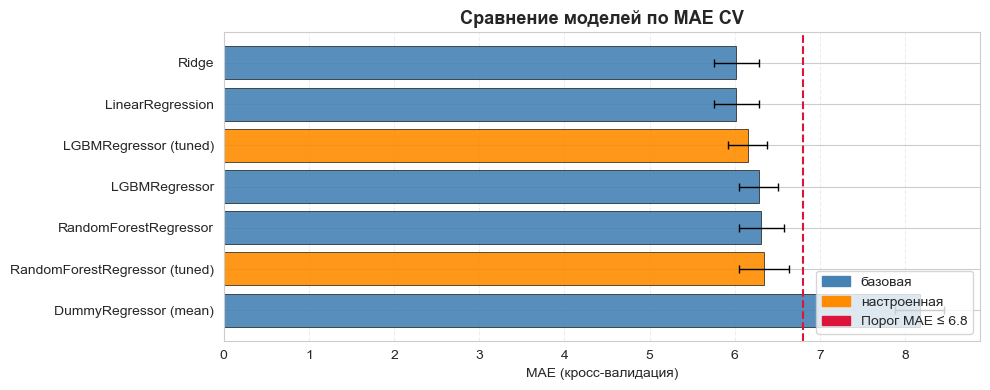


Лучшая модель по CV: Ridge  (MAE CV = 6.0179)

ФИНАЛЬНАЯ ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ (один раз)
Модель:              Ridge
MAE CV (валидация):  6.0179 °C
MAE test (финал):    6.0013 °C
Разница test - CV:   -0.0166 °C
Критерий MAE ≤ 6.8 °C:   ✅ ВЫПОЛНЕН  (MAE test = 6.0013)
Saved: ../images/Ridge_test_predictions.png


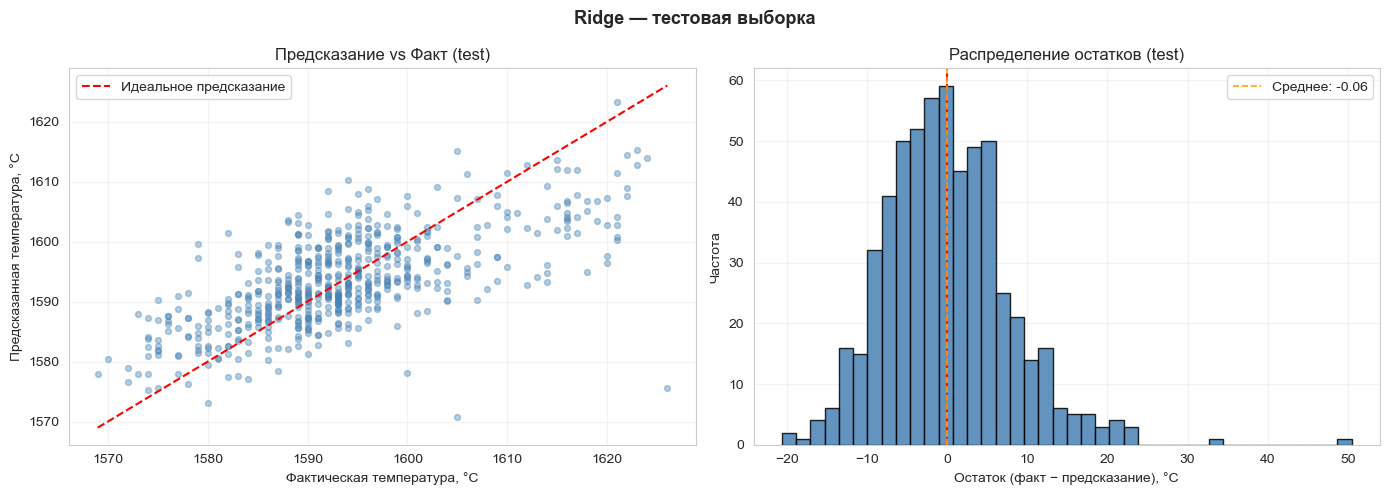

Saved: ../images/Ridge_top_15_coefficients.png


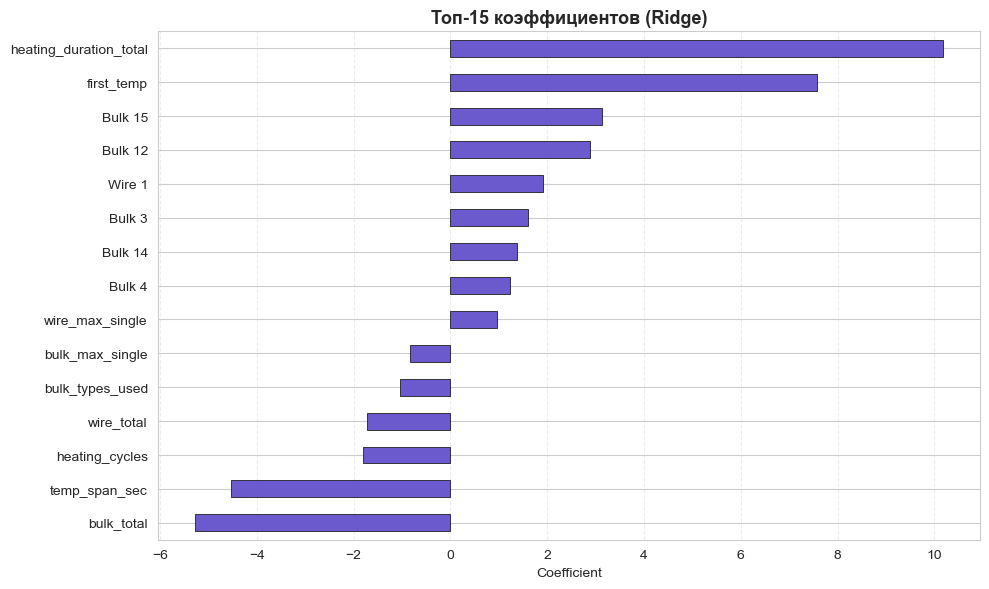

In [37]:
# --- итоговое сравнение всех моделей по CV ---
baseline_src = baseline_results if 'baseline_results' in globals() else {}
tuned_src = (
	final_tuned_results if 'final_tuned_results' in globals()
	else tuning_results if 'tuning_results' in globals()
	else {}
)

all_summary = []

for name, res in baseline_src.items():
	mae_cv = res.get('MAE CV (mean)', res.get('MAE CV'))
	mae_cv_std = res.get('MAE CV (std)', res.get('MAE CV std'))
	estimator = res.get('model', res.get('best_estimator'))

	if mae_cv is not None and estimator is not None:
		all_summary.append({
			'модель': name,
			'MAE CV': float(mae_cv),
			'MAE CV std': float(mae_cv_std) if mae_cv_std is not None else None,
			'настроена': 'нет',
			'estimator': estimator
		})

for name, res in tuned_src.items():
	mae_cv = res.get('MAE CV (full train)', res.get('MAE CV', res.get('MAE CV (tuned)', res.get('MAE CV (mean)'))))
	mae_cv_std = res.get('MAE CV (std)', res.get('MAE CV std'))
	estimator = res.get('best_estimator', res.get('model'))

	if mae_cv is not None and estimator is not None:
		all_summary.append({
			'модель': f'{name} (tuned)',
			'MAE CV': float(mae_cv),
			'MAE CV std': float(mae_cv_std) if mae_cv_std is not None else None,
			'настроена': 'да',
			'estimator': estimator
		})

if not all_summary:
	raise ValueError('Не найдены результаты моделей в baseline_results / final_tuned_results / tuning_results.')

all_summary_df = (
	pd.DataFrame(all_summary)
	.dropna(subset=['MAE CV'])
	.sort_values('MAE CV', ascending=True)
	.reset_index(drop=True)
)

all_summary_df.insert(0, 'rank', all_summary_df.index + 1)

print('Итоговое сравнение всех моделей по CV на полном X_train:')
display(all_summary_df.drop(columns='estimator'))

fig, ax = plt.subplots(figsize=(10, max(4, 0.55 * len(all_summary_df))))
colors = ['steelblue' if t == 'нет' else 'darkorange' for t in all_summary_df['настроена']]

ax.barh(
	all_summary_df['модель'],
	all_summary_df['MAE CV'],
	xerr=all_summary_df['MAE CV std'],
	color=colors,
	edgecolor='black',
	linewidth=0.5,
	alpha=0.9,
	error_kw={'elinewidth': 1, 'capsize': 3, 'ecolor': 'black'}
)
ax.set_xlabel('MAE (кросс-валидация)')
ax.set_title('Сравнение моделей по MAE CV', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.axvline(quality_threshold, color='crimson', linestyle='--', linewidth=1.5)
ax.grid(axis='x', linestyle='--', alpha=0.35)
ax.legend(
	handles=[
		Patch(color='steelblue', label='базовая'),
		Patch(color='darkorange', label='настроенная'),
		Patch(color='crimson', label=f'Порог MAE ≤ {quality_threshold}')
	],
	loc='lower right'
)
plt.tight_layout()
save_plot('all_models_comparison_mae_cv')
plt.show()

# --- выбор лучшей модели по CV ---
best_row = all_summary_df.loc[all_summary_df['MAE CV'].idxmin()]
best_name = best_row['модель']
best_model = best_row['estimator']
best_cv_mae = float(best_row['MAE CV'])

print(f'\nЛучшая модель по CV: {best_name}  (MAE CV = {best_cv_mae:.4f})')

# --- финальная проверка на тестовой выборке — ОДИН РАЗ ---
print('\n' + '=' * 55)
print('ФИНАЛЬНАЯ ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ (один раз)')
print('=' * 55)

y_pred_test = best_model.predict(X_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
test_gap = mae_test - best_cv_mae

print(f'Модель:              {best_name}')
print(f'MAE CV (валидация):  {best_cv_mae:.4f} °C')
print(f'MAE test (финал):    {mae_test:.4f} °C')
print(f'Разница test - CV:   {test_gap:+.4f} °C')
threshold_ok = mae_test <= quality_threshold
status = '✅ ВЫПОЛНЕН' if threshold_ok else '❌ НЕ ВЫПОЛНЕН'
print(f'Критерий MAE ≤ {quality_threshold} °C:   {status}  (MAE test = {mae_test:.4f})')
print('=' * 55)

# --- визуализация ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.4, s=18, color='steelblue')
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot(
	[min_val, max_val], [min_val, max_val],
	'r--', linewidth=1.5, label='Идеальное предсказание'
)
axes[0].set_xlabel('Фактическая температура, °C')
axes[0].set_ylabel('Предсказанная температура, °C')
axes[0].set_title('Предсказание vs Факт (test)', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.25)

residuals = y_test.to_numpy() - y_pred_test
axes[1].hist(residuals, bins=40, edgecolor='black', color='steelblue', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(
	residuals.mean(),
	color='orange',
	linestyle='--',
	linewidth=1.2,
	label=f'Среднее: {residuals.mean():.2f}'
)
axes[1].set_xlabel('Остаток (факт − предсказание), °C')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение остатков (test)', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.suptitle(f'{best_name} — тестовая выборка', fontsize=13, fontweight='bold')
plt.tight_layout()
save_plot(f'{best_name}_test_predictions')
plt.show()

# --- важность признаков ---
inner_model = best_model.named_steps['model'] if hasattr(best_model, 'named_steps') else best_model

if hasattr(inner_model, 'feature_importances_'):
	feat_imp = pd.Series(inner_model.feature_importances_, index=X_train.columns).sort_values()
	feat_imp_top = feat_imp.tail(15)

	fig, ax = plt.subplots(figsize=(10, 6))
	feat_imp_top.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black', linewidth=0.5)
	ax.set_title(f'Топ-15 важных признаков ({best_name})', fontsize=13, fontweight='bold')
	ax.set_xlabel('Feature importance')
	ax.grid(axis='x', linestyle='--', alpha=0.35)
	plt.tight_layout()
	save_plot(f'{best_name}_feature_importances')
	plt.show()

elif hasattr(inner_model, 'coef_'):
	coef = pd.Series(inner_model.coef_, index=X_train.columns)
	coef_top = coef.abs().sort_values().tail(15).index
	coef_view = coef.loc[coef_top].sort_values()

	fig, ax = plt.subplots(figsize=(10, 6))
	coef_view.plot(kind='barh', ax=ax, color='slateblue', edgecolor='black', linewidth=0.5)
	ax.set_title(f'Топ-15 коэффициентов ({best_name})', fontsize=13, fontweight='bold')
	ax.set_xlabel('Coefficient')
	ax.grid(axis='x', linestyle='--', alpha=0.35)
	plt.tight_layout()
	save_plot(f'{best_name}_top_15_coefficients')
	plt.show()

else:
	print(f'Для модели {best_name} важности признаков недоступны.')

После честного сравнения всех моделей по одной и той же схеме 5-кратной кросс-валидации на полном `X_train` лучшей оказалась модель `Ridge`.

Она показала минимальное значение ошибки на валидации — **MAE CV = 6.0179**, опередив как базовую `LinearRegression`, так и настроенные ансамблевые модели. Это означает, что в рамках текущего набора признаков наиболее устойчивым решением оказалась именно регуляризованная линейная модель. Вероятнее всего, это связано с объёмом обучающей выборки: после всех этапов фильтрации она оказалась достаточно небольшой, а на небольших выборках регуляризованные линейные модели зачастую обобщают лучше ансамблевых.

После выбора лучшей модели была выполнена её финальная проверка на тестовой выборке, которая до этого момента не использовалась ни для обучения, ни для отбора моделей, ни для подбора гиперпараметров. На тесте модель `Ridge` показала **MAE = 6.0013**, что не только ниже требуемого порога **6.8**, но и практически совпадает с результатом кросс-валидации.

Близость значений `MAE CV` и `MAE test` показывает, что модель хорошо обобщает данные и не демонстрирует заметного переобучения. Следовательно, требование задачи по качеству выполнено.

**Вывод:** лучшей моделью по итогам сравнения оказалась `Ridge`. На тестовой выборке она достигла значения **MAE = 6.0022**, что удовлетворяет требованию задачи (**MAE ≤ 6.8**). Отдельного подбора гиперпараметров для `Ridge` не проводилось: базовая версия уже показала лучший результат среди всех моделей, поэтому дополнительный тюнинг был нецелесообразен.

## Интерпретация модели: SHAP

Три визуализации:
- **Beeswarm** — распределение SHAP-значений по всем объектам теста; цвет показывает величину признака
- **Bar plot** — средний |SHAP| по всей выборке; аналог feature importance, но честнее
- **Waterfall** — детальный разбор одного объекта: из чего складывается конкретное предсказание

Saved: ../images/Ridge_shap_summary_plot.png


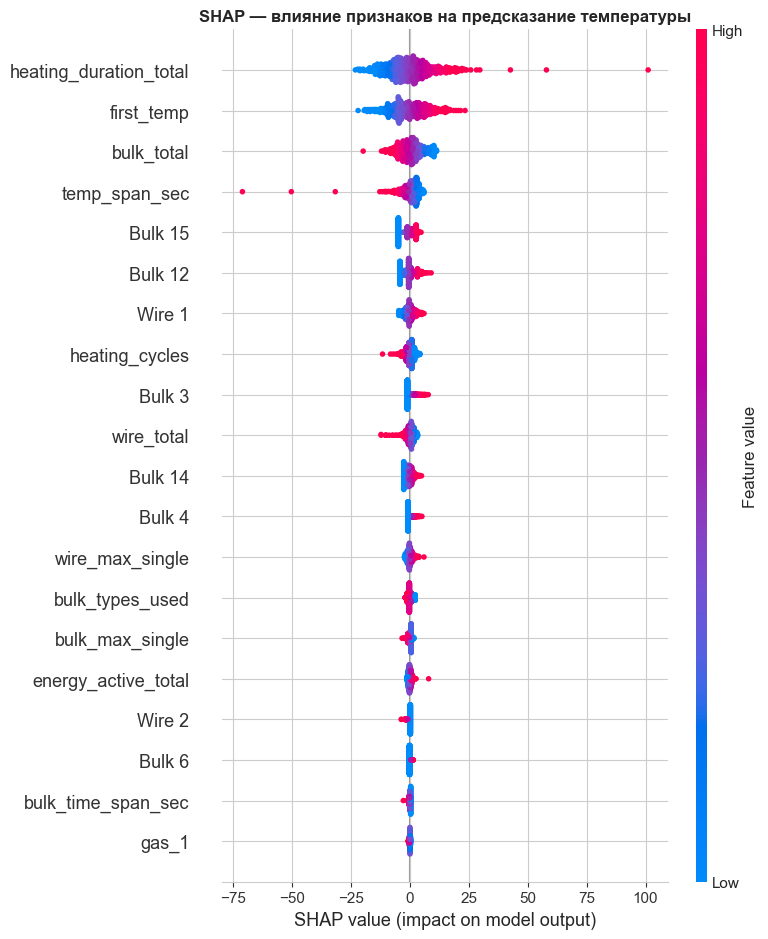

Saved: ../images/Ridge_shap_summary_bar_plot.png


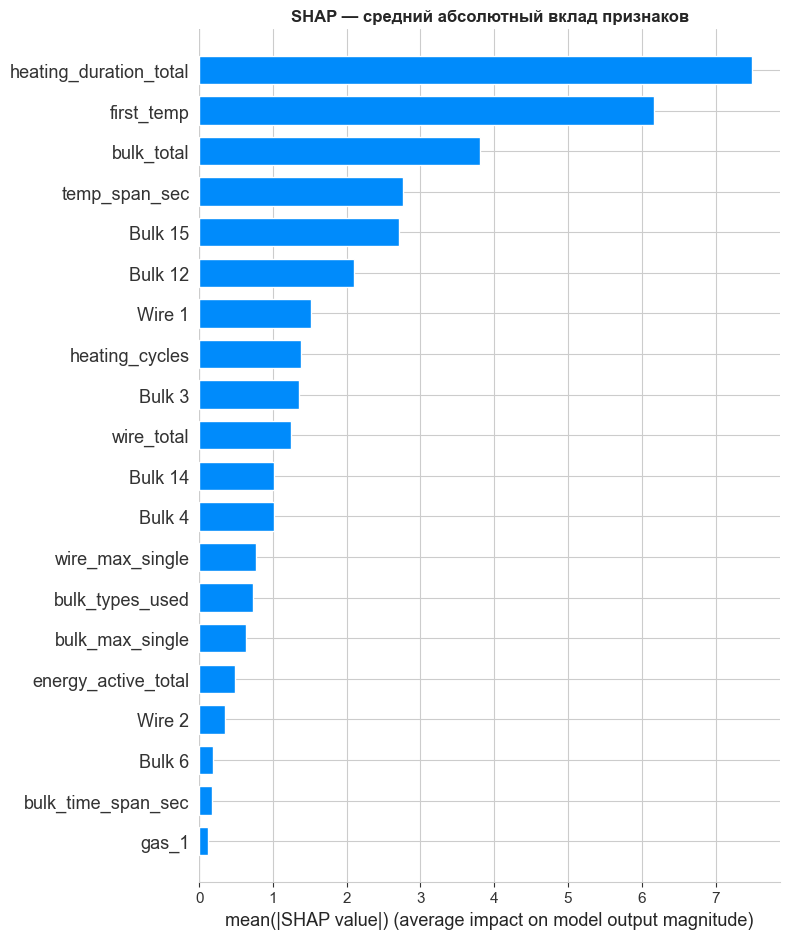

Saved: ../images/Ridge_shap_waterfall_example.png


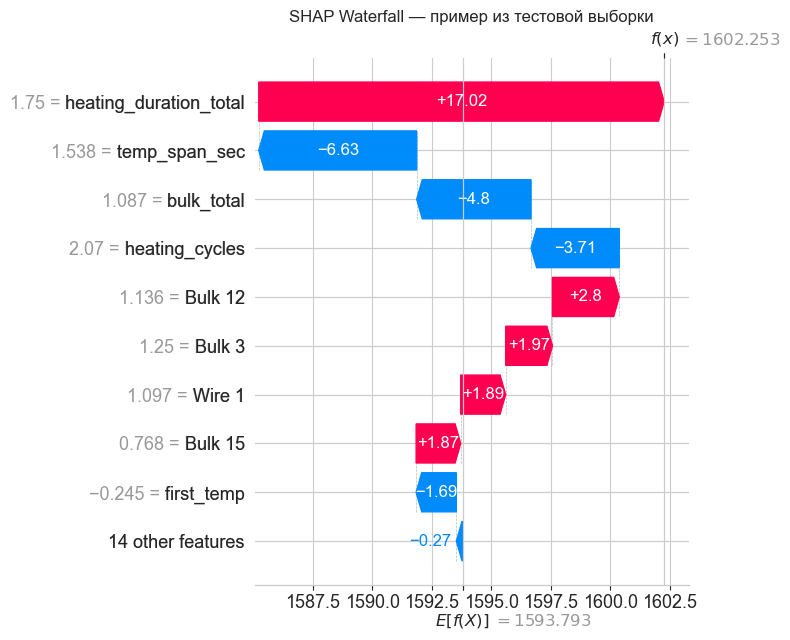

In [38]:
inner_model = best_model.named_steps['model']

# Трансформируем данные через все шаги Pipeline кроме последнего (модели)
X_test_tr  = best_model[:-1].transform(X_test)
X_train_tr = best_model[:-1].transform(X_train)
feature_names = X_test.columns.tolist()

# Выбираем Explainer в зависимости от типа модели
if hasattr(inner_model, 'feature_importances_'):
    explainer = shap.TreeExplainer(inner_model)
elif hasattr(inner_model, 'coef_'):
    explainer = shap.LinearExplainer(inner_model, shap.sample(X_train_tr, 100))
else:
    bg = shap.sample(X_train_tr, 100)
    explainer = shap.KernelExplainer(inner_model.predict, bg)

shap_values = explainer.shap_values(X_test_tr)

# --- Summary plot (beeswarm) ---
shap.summary_plot(shap_values, X_test_tr, feature_names=feature_names, show=False)
plt.title('SHAP — влияние признаков на предсказание температуры', fontsize=12, fontweight='bold')
plt.tight_layout()
save_plot(f'{best_name}_shap_summary_plot')
plt.show()

# --- Bar plot: средний |SHAP| ---
shap.summary_plot(shap_values, X_test_tr, feature_names=feature_names,
                  plot_type='bar', show=False)
plt.title('SHAP — средний абсолютный вклад признаков', fontsize=12, fontweight='bold')
plt.tight_layout()
save_plot(f'{best_name}_shap_summary_bar_plot')
plt.show()

# --- Waterfall для одного объекта ---
shap_exp = shap.Explanation(
    values=shap_values[0],
    base_values=float(explainer.expected_value)
        if not hasattr(explainer.expected_value, '__len__')
        else float(explainer.expected_value[0]),
    data=X_test_tr[0],
    feature_names=feature_names
)
shap.plots.waterfall(shap_exp, show=False)
plt.title('SHAP Waterfall — пример из тестовой выборки', fontsize=12)
plt.tight_layout()
save_plot(f'{best_name}_shap_waterfall_example')
plt.show()


### Вывод по SHAP-анализу

Чтобы понять, какие признаки сильнее всего влияют на предсказание температуры, для лучшей модели был проведён SHAP-анализ.

График среднего абсолютного вклада признаков показывает, что наибольшее влияние на предсказание оказывают `heating_duration_total`, `first_temp`, `bulk_total` и `temp_span_sec`. Это хорошо согласуется с предметной логикой задачи: итоговая температура партии должна зависеть как от исходной температуры, так и от длительности и интенсивности обработки.

По summary plot видно не только силу влияния признаков, но и его направление. Так, более высокие значения `heating_duration_total` и `first_temp` чаще сдвигают предсказание температуры вверх. В то же время влияние некоторых признаков, например `bulk_total` и `temp_span_sec`, более сложное и не сводится к простой линейной зависимости: в разных диапазонах значений они могут как повышать, так и понижать прогноз модели.

Признаки, связанные с отдельными материалами, например `Bulk 15`, `Bulk 12`, `Wire 1`, `Bulk 3`, `Bulk 14` и `Bulk 4`, также вносят заметный вклад, хотя и уступают по важности основным технологическим характеристикам. Это подтверждает, что модель учитывает не только общий режим нагрева, но и особенности состава добавок.

Waterfall-график для отдельного объекта показывает, как формируется конкретное предсказание. В рассмотренном примере базовое значение прогноза последовательно изменяется под влиянием признаков: наибольший вклад в сторону повышения температуры вносит `heating_duration_total`, тогда как `temp_span_sec`, `bulk_total` и `heating_cycles` в данном случае сдвигают прогноз вниз. Такой разбор позволяет увидеть, как модель приходит к итоговому значению для конкретной партии.

**Вывод:** SHAP-анализ показал, что модель в первую очередь опирается на признаки, связанные с длительностью нагрева, исходной температурой и общими характеристиками обработки партии. При этом заметную роль играют и отдельные добавки, что делает поведение модели содержательно интерпретируемым.

## Статистическая оценка результатов

Чтобы дополнительно проверить устойчивость полученного результата, были использованы два независимых подхода.

**1. Wilcoxon signed-rank test**  
С его помощью проверяется, что ошибка лучшей модели на одних и тех же фолдах кросс-валидации систематически ниже, чем у `DummyRegressor`. Тест непараметрический и не требует предположения о нормальности распределения.

**2. Bootstrap-доверительный интервал для MAE на тестовой выборке**  
Этот подход позволяет оценить неопределённость итоговой тестовой метрики. Для этого на тестовой выборке были построены 1000 бутстреп-выборок с возвращением, после чего рассчитан 95%-й доверительный интервал для MAE.


Модель                              MAE CV (mean) MAE CV (std)
--------------------------------------------------------------
Ridge                                      6.0333       0.3574
DummyRegressor                             8.1723       0.1754

Wilcoxon signed-rank test (H₁: MAE лучшей модели < MAE DummyRegressor):
  MAE по фолдам — лучшая модель: [5.577, 5.8517, 6.574, 6.3058, 5.858]
  MAE по фолдам — DummyRegressor: [8.2716, 8.3399, 8.0495, 8.3128, 7.8877]
  Статистика W = 0.0000,  p-value = 0.0312
  → Различие статистически значимо (p < 0.05): лучшая модель достоверно лучше baseline.
Примечание: при 5 фолдах минимально достижимое p-value = 0.03125; мощность теста ограничена.
Saved: ../images/Ridge_vs_dummy_mae_cv_folds.png


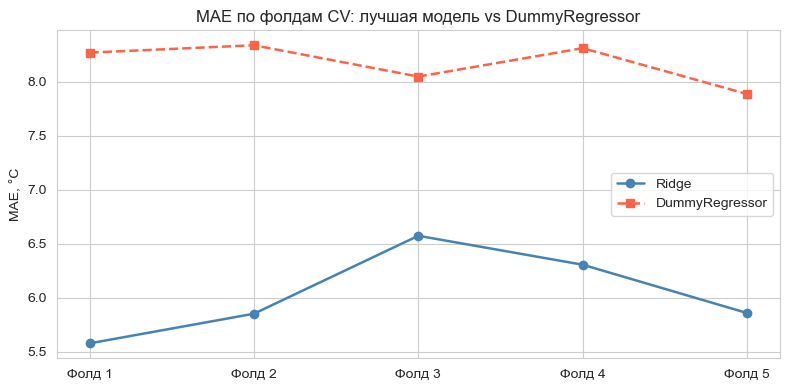

Exception ignored in: <function ResourceTracker.__del__ at 0x10cbddbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10f4f5bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10f1b1bc0>
Traceback (most recent call last

In [ ]:

cv_stat = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# MAE по фолдам для лучшей модели (cross_val_score клонирует estimator — корректно)
best_fold_maes = -cross_val_score(
    best_model, X_train, y_train,
    cv=cv_stat, scoring='neg_mean_absolute_error', n_jobs=-1
)

# MAE по фолдам для DummyRegressor
dummy_pipeline = make_plain_pipeline(DummyRegressor(strategy='mean'))
dummy_fold_maes = -cross_val_score(
    dummy_pipeline, X_train, y_train,
    cv=cv_stat, scoring='neg_mean_absolute_error', n_jobs=-1
)

print(f'{"Модель":<35} {"MAE CV (mean)":>13} {"MAE CV (std)":>12}')
print('-' * 62)
print(f'{best_name:<35} {best_fold_maes.mean():>13.4f} {best_fold_maes.std():>12.4f}')
print(f'{"DummyRegressor":<35} {dummy_fold_maes.mean():>13.4f} {dummy_fold_maes.std():>12.4f}')

# Wilcoxon signed-rank test: проверяем, что MAE лучшей модели меньше MAE Dummy
stat, p_value = wilcoxon(best_fold_maes, dummy_fold_maes, alternative='less')

print()
print('Wilcoxon signed-rank test (H₁: MAE лучшей модели < MAE DummyRegressor):')
print(f'  MAE по фолдам — лучшая модель: {best_fold_maes.round(4).tolist()}')
print(f'  MAE по фолдам — DummyRegressor: {dummy_fold_maes.round(4).tolist()}')
print(f'  Статистика W = {stat:.4f},  p-value = {p_value:.4f}')
if p_value < 0.05:
    print(f'  → Различие статистически значимо (p < 0.05): лучшая модель достоверно лучше baseline.')
else:
    print(f'  → Различие не достигает статистической значимости (p ≥ 0.05).')

print('Примечание: при 5 фолдах минимально достижимое p-value = 0.03125; мощность теста ограничена.')

# Визуализация MAE по фолдам
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(1, 6)
ax.plot(x, best_fold_maes, 'o-', color='steelblue', label=f'{best_name}', linewidth=1.8)
ax.plot(x, dummy_fold_maes, 's--', color='tomato', label='DummyRegressor', linewidth=1.8)
ax.set_xticks(x)
ax.set_xticklabels([f'Фолд {i}' for i in x])
ax.set_ylabel('MAE, °C')
ax.set_title('MAE по фолдам CV: лучшая модель vs DummyRegressor', fontsize=12)
ax.legend()
plt.tight_layout()
save_plot(f'{best_name}_vs_dummy_mae_cv_folds')
plt.show()

MAE на тестовой выборке:  6.0013 °C
Bootstrap 95% CI:         [5.6042, 6.4458] °C
Ширина интервала:         0.8417 °C
Saved: ../images/Ridge_bootstrap_mae_test.png


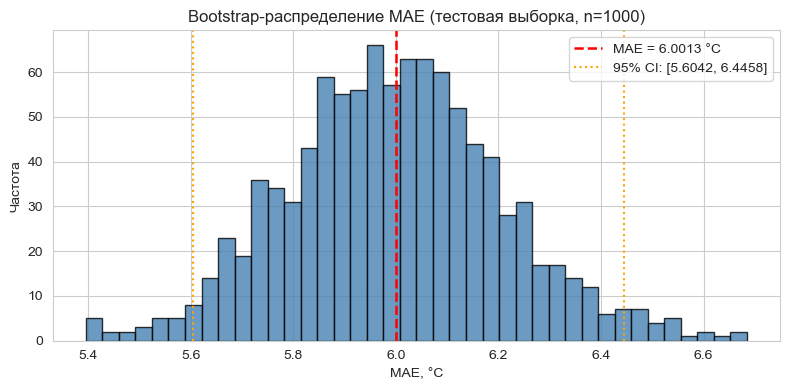

Exception ignored in: <function ResourceTracker.__del__ at 0x10f431bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x110c3dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10d685bc0>
Traceback (most recent call last

In [40]:
rng = np.random.default_rng(RANDOM_STATE)
n_bootstrap = 1000
boot_maes = []

for _ in range(n_bootstrap):
    idx = rng.integers(0, len(y_test), size=len(y_test))
    boot_mae = mean_absolute_error(y_test.values[idx], y_pred_test[idx])
    boot_maes.append(boot_mae)

boot_maes = np.array(boot_maes)
ci_low, ci_high = np.percentile(boot_maes, [2.5, 97.5])

print(f'MAE на тестовой выборке:  {mae_test:.4f} °C')
print(f'Bootstrap 95% CI:         [{ci_low:.4f}, {ci_high:.4f}] °C')
print(f'Ширина интервала:         {ci_high - ci_low:.4f} °C')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_maes, bins=40, color='steelblue', edgecolor='black', alpha=0.8)
ax.axvline(mae_test, color='red', linestyle='--', linewidth=1.8, label=f'MAE = {mae_test:.4f} °C')
ax.axvline(ci_low,  color='orange', linestyle=':', linewidth=1.5,
           label=f'95% CI: [{ci_low:.4f}, {ci_high:.4f}]')
ax.axvline(ci_high, color='orange', linestyle=':', linewidth=1.5)
ax.set_xlabel('MAE, °C')
ax.set_ylabel('Частота')
ax.set_title('Bootstrap-распределение MAE (тестовая выборка, n=1000)', fontsize=12)
ax.legend()
plt.tight_layout()
save_plot(f'{best_name}_bootstrap_mae_test')
plt.show()

### Результаты

По результатам кросс-валидации средний `MAE` модели `Ridge` составил **6.0333**, тогда как у `DummyRegressor` он равен **8.1723**.  
Wilcoxon signed-rank test дал значение **p = 0.0312**, что меньше уровня значимости 0.05. Это позволяет сделать вывод, что модель `Ridge` статистически значимо лучше baseline-модели.

На тестовой выборке модель показала **MAE = 6.0013 °C**. Построенный bootstrap 95% confidence interval равен **[5.6042; 6.4458] °C**. Интервал достаточно узкий и полностью лежит ниже порогового значения **6.8 °C**, что дополнительно подтверждает устойчивость результата и выполнение требования задачи.

## Общий вывод

В ходе проекта были загружены и проанализированы семь таблиц, описывающих разные этапы обработки стали: нагрев электродами, продувку газом, подачу сыпучих и проволочных материалов, а также измерения температуры.

На этапе **исследовательского анализа и предобработки** были выявлены основные особенности данных. Таблицы имеют событийную структуру: одной партии соответствует несколько записей. Пропуски в bulk- и wire-признаках интерпретированы как отсутствие подачи соответствующих материалов. Для построения целевой выборки были оставлены только партии, в которых есть минимум два валидных измерения температуры. Также из данных были удалены явные аномалии: нереалистичные значения температуры и одна строка с некорректной реактивной мощностью в таблице `arc`.

На этапе **формирования признаков** данные были агрегированы по партии. Для нагрева рассчитаны длительность обработки, число циклов и энергетические характеристики. Для bulk- и wire-таблиц получены как отдельные признаки по материалам, так и агрегированные показатели: суммарные объёмы, число использованных типов и временные интервалы подачи. Для таблицы температур были сформированы `first_temp`, `target_temp`, `temp_count` и `temp_span_sec`. Целевым признаком выбрана последняя измеренная температура партии.

После объединения таблиц был сформирован итоговый датасет. Дополнительно выполнен анализ распределений, выбросов и связей между признаками. Корреляционный анализ показал, что наиболее содержательно с финальной температурой связаны `first_temp`, признаки нагрева и часть агрегированных характеристик обработки. На этапе подготовки данных были исключены слишком разреженные признаки, а также часть слабых и дублирующих друг друга переменных.

Для решения задачи были обучены базовые модели `LinearRegression`, `Ridge`, `RandomForestRegressor`, `LGBMRegressor` и `DummyRegressor` как baseline. Сравнение выполнялось по MAE на 5-кратной кросс-валидации на обучающей выборке. Лучший результат среди базовых моделей показала `Ridge`. Для ансамблевых моделей дополнительно был выполнен подбор гиперпараметров, после чего они были повторно оценены на полном `X_train` по той же схеме кросс-валидации. Несмотря на улучшение `LGBMRegressor`, лучшей моделью по итоговому значению `MAE CV` осталась `Ridge`.

Финальная проверка лучшей модели на тестовой выборке была выполнена один раз, после завершения всех этапов отбора и настройки. Модель `Ridge` показала:

- **MAE CV = 6.0179 **
- **MAE test = 6.0013**

Таким образом, требование задачи выполнено: итоговая ошибка на тестовой выборке оказалась ниже порогового значения **6.8**.

Дополнительная статистическая проверка показала, что преимущество модели над baseline не случайно, а bootstrap-интервал для тестового `MAE` полностью лежит ниже требуемого порога. Это позволяет считать полученный результат устойчивым.

Итоговый вывод: для данной задачи наиболее удачной оказалась регуляризованная линейная модель `Ridge`. Она показала лучшее сочетание качества, устойчивости и интерпретируемости. Построенная модель может быть использована для прогнозирования финальной температуры сплава и в дальнейшем — как часть системы имитации технологического процесса и оптимизации энергозатрат.

### Рекомендации заказчику

1. **Точнее контролировать начальную температуру партии.**  
   `first_temp` оказался одним из самых важных признаков в модели, поэтому стабильный и точный контроль температуры до начала основной обработки напрямую влияет на качество прогноза и на возможность точнее управлять дальнейшим нагревом.

2. **Использовать модель для настройки режима нагрева.**  
   Существенный вклад в прогноз вносят признаки, связанные с длительностью нагрева и суммарной энергией обработки. Это означает, что модель можно использовать как инструмент для более точного подбора режима работы электродов и снижения избыточных энергозатрат.

3. **Применять модель как инструмент сценарного анализа.**  
   Модель позволяет заранее оценивать, к какой финальной температуре приведёт выбранная комбинация начальной температуры, длительности нагрева и объёма добавок. Это делает её полезной не только для прогноза, но и для имитации технологических сценариев без необходимости проводить лишние реальные прогоны.

4. **Отслеживать влияние добавок вместе с температурным режимом.**  
   Хотя главными факторами остаются начальная температура и характеристики нагрева, признаки материалов тоже вносят вклад в итоговый прогноз. Поэтому контроль подачи bulk- и wire-материалов имеет смысл вести не отдельно, а в связке с температурными параметрами процесса.

5. **Периодически переобучать модель на новых данных.**  
   По мере накопления новых партий модель стоит обновлять, чтобы она продолжала учитывать текущие особенности сырья, оборудования и режима работы производства. Это позволит поддерживать качество прогноза на стабильном уровне.

## Отчёт

### 1. Какие пункты плана были выполнены, а какие — нет?

План работы выполнен полностью.

1. ✅ Загружены и проверены все исходные таблицы.
2. ✅ Выполнен первичный осмотр данных: структура, типы, пропуски, дубликаты, число уникальных партий.
3. ✅ Проведён исследовательский анализ и предобработка отдельных таблиц.
4. ✅ Выполнена агрегация признаков по партии и сформирован единый датасет.
5. ✅ Проведён исследовательский анализ объединённого датасета: распределения, выбросы, корреляции, phik-анализ.
6. ✅ Выполнен инжиниринг признаков и отбор признаков для моделирования.
7. ✅ Обучены базовые модели: `LinearRegression`, `Ridge`, `RandomForestRegressor`, `LGBMRegressor`, `DummyRegressor`.
8. ✅ Для ансамблевых моделей выполнен подбор гиперпараметров с помощью `RandomizedSearchCV`.
9. ✅ Лучшая модель выбрана по кросс-валидации и один раз проверена на тестовой выборке.
10. ✅ Проведена интерпретация модели с помощью SHAP и анализа важности признаков.
11. ✅ Сформулированы общий вывод и рекомендации для заказчика.

---

### 2. Какие трудности возникли и как вы их преодолели?

- **Событийная структура данных.**  
  Одна партия представлена несколькими строками в разных таблицах. Чтобы перейти к формату, пригодному для обучения модели, признаки были агрегированы по `key`.

- **Пропуски в таблицах материалов.**  
  В bulk- и wire-признаках пропуски в большинстве случаев означают не потерю данных, а отсутствие подачи соответствующего материала. Поэтому после агрегации такие значения были заменены нулями.

- **Формирование целевого признака.**  
  В таблице температуры для одной партии содержится несколько измерений. В качестве целевого признака была выбрана последняя валидная температура партии, а в выборку включены только партии с минимум двумя валидными замерами.

- **Риск утечки данных.**  
  Некоторые температурные признаки (`mean_temp`, `min_temp`, `max_temp`, `temp_delta`) используют информацию из всей траектории измерений, включая финальную температуру. Поэтому они были рассчитаны только для анализа и исключены из обучающей матрицы.

- **Разреженные признаки.**  
  Часть материалов используется слишком редко и создаёт сильную разреженность. Для таких признаков была рассчитана доля ненулевых значений, после чего признаки с долей менее 10% были исключены.

- **Слабые и дублирующие признаки.**  
  Часть признаков показала нулевую phik-корреляцию с целевой переменной или практически полностью дублировала другие признаки. Такие переменные были исключены до этапа обучения.

---

### 3. Какие ключевые шаги в решении задачи выделили?

1. **Корректное формирование целевой выборки.**  
   В модель включались только партии с достаточным числом валидных измерений температуры.

2. **Агрегация событийных данных по партии.**  
   Без этого шага данные из разных таблиц нельзя было бы корректно объединить и использовать в модели.

3. **Осмысленная предобработка признаков.**  
   Пропуски были интерпретированы с учётом предметной области, а аномальные строки удалены как явные выбросы.

4. **Отбор признаков перед обучением.**  
   Из модели были исключены слишком разреженные, слабые и дублирующие признаки, что позволило сделать итоговую матрицу признаков чище и устойчивее.

5. **Корректная схема валидации.**  
   Выбор модели проводился по кросс-валидации на обучающей выборке, а тестовая выборка использовалась только один раз в самом конце.

6. **Использование `Pipeline`.**  
   Весь препроцессинг был встроен в пайплайн, что позволило избежать утечки данных при кросс-валидации.

7. **Интерпретация результата.**  
   Дополнительно был проведён SHAP-анализ, чтобы понять не только важность признаков, но и направление их влияния на предсказание.